In [1]:
pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.0 MB/s eta 0:00:00


In [13]:
# -*- coding: utf-8 -*-
"""
단계 1: 개선된 지식 그래프 구축 (별칭 및 그룹 정보 포함)
출력 파일:
  - node2id.json
  - id2node.json
  - alias_to_primary.json (★ 새로 추가)
  - artist_info.json (★ 새로 추가)
  - node_types.json (★ 새로 추가)
  - kg_edges.npy
"""

import pandas as pd
import numpy as np
import json
import os
import warnings

warnings.filterwarnings('ignore')

print("="*70)
print("단계 1: 개선된 지식 그래프 구축")
print("="*70)

# ===================================================================
# 1. 경로 설정 및 데이터 로드
# ===================================================================
BASE_PATH = "/content/drive/MyDrive/"
K_DATA_PATH = os.path.join(BASE_PATH, "melon/k_data.csv")

try:
    k_data_df = pd.read_csv(K_DATA_PATH)
    print(f"\n✓ Kaggle K-pop 데이터 로드 완료")
    print(f"  - 아이돌 수: {len(k_data_df):,}명")
except Exception as e:
    print(f"\n❌ 데이터 로드 실패: {e}")
    print(f"경로 확인: {K_DATA_PATH}")
    exit()

# ===================================================================
# 2. 아티스트별 별칭(alias) 수집
# ===================================================================
print(f"\n{'='*70}")
print("2-1. 아티스트 별칭 수집")
print(f"{'='*70}")

artist_aliases = {}      # primary_name -> [list of aliases]
artist_info = {}         # primary_name -> {group, korean_group, ...}

for _, row in k_data_df.iterrows():
    stage_name = row['Stage Name']
    if pd.isna(stage_name):
        continue

    # Stage Name을 primary key로 사용
    primary_name = stage_name

    # 별칭 수집
    aliases = [stage_name]  # 자기 자신

    # Korean Name 추가
    if pd.notna(row['Korean Name']):
        korean_name = row['Korean Name']
        if korean_name not in aliases:
            aliases.append(korean_name)

    # K Stage Name 추가
    if pd.notna(row['K Stage Name']):
        k_stage = row['K Stage Name']
        if k_stage not in aliases:
            aliases.append(k_stage)

    artist_aliases[primary_name] = aliases

    # 아티스트 메타 정보 저장
    artist_info[primary_name] = {
        'group': row['Group'] if pd.notna(row['Group']) else None,
        'korean_group': row['Korean_Group_Name'] if pd.notna(row['Korean_Group_Name']) else None,
        'korean_name': row['Korean Name'] if pd.notna(row['Korean Name']) else None,
        'k_stage_name': row['K Stage Name'] if pd.notna(row['K Stage Name']) else None
    }

print(f"✓ 고유 아티스트: {len(artist_aliases):,}명")
print(f"✓ 평균 별칭 수: {np.mean([len(v) for v in artist_aliases.values()]):.1f}개")

# 샘플 출력
print(f"\n별칭 샘플 (처음 10명):")
for i, (primary, aliases) in enumerate(list(artist_aliases.items())[:10]):
    print(f"  {i+1}. {primary}")
    print(f"     별칭: {', '.join(aliases)}")

# ===================================================================
# 3. 그룹 정보 수집
# ===================================================================
print(f"\n{'='*70}")
print("2-2. 그룹 정보 수집")
print(f"{'='*70}")

unique_groups = set()
for info in artist_info.values():
    if info['group']:
        unique_groups.add(info['group'])

print(f"✓ 고유 그룹: {len(unique_groups):,}개")

# 그룹별 멤버 수 통계
from collections import defaultdict
group_member_count = defaultdict(int)
for info in artist_info.values():
    if info['group']:
        group_member_count[info['group']] += 1

top_groups = sorted(group_member_count.items(), key=lambda x: -x[1])[:10]
print(f"\n멤버 수 Top 10 그룹:")
for i, (group, count) in enumerate(top_groups, 1):
    print(f"  {i}. {group}: {count}명")

# ===================================================================
# 4. 노드 ID 할당
# ===================================================================
print(f"\n{'='*70}")
print("2-3. 노드 ID 할당")
print(f"{'='*70}")

# 아티스트와 그룹의 primary name 정렬
artist_primary_names = sorted(list(artist_aliases.keys()))
group_names = sorted(list(unique_groups))

num_artists = len(artist_primary_names)
num_groups = len(group_names)

# 노드 ID 매핑
# - 아티스트: 0 ~ (num_artists - 1)
# - 그룹: num_artists ~ (num_artists + num_groups - 1)
artist2id = {name: i for i, name in enumerate(artist_primary_names)}
group2id = {name: i + num_artists for i, name in enumerate(group_names)}

node2id = {**artist2id, **group2id}
id2node = {i: name for name, i in node2id.items()}

print(f"✓ 총 노드 수: {len(node2id):,}개")
print(f"  - 아티스트: {num_artists:,}개")
print(f"  - 그룹: {num_groups:,}개")

# ===================================================================
# 5. 별칭 → Primary Name 매핑 생성
# ===================================================================
print(f"\n{'='*70}")
print("2-4. 별칭 매핑 생성")
print(f"{'='*70}")

alias_to_primary = {}
duplicate_aliases = []

for primary_name, aliases in artist_aliases.items():
    for alias in aliases:
        if alias in alias_to_primary:
            # 중복 별칭 발견
            duplicate_aliases.append({
                'alias': alias,
                'primary1': alias_to_primary[alias],
                'primary2': primary_name
            })
        alias_to_primary[alias] = primary_name

print(f"✓ 별칭 매핑: {len(alias_to_primary):,}개")

if duplicate_aliases:
    print(f"\n⚠️ 중복 별칭 발견: {len(duplicate_aliases)}개")
    for dup in duplicate_aliases[:5]:  # 처음 5개만 출력
        print(f"  - '{dup['alias']}' → {dup['primary1']} vs {dup['primary2']}")
else:
    print(f"✓ 중복 별칭 없음")

# ===================================================================
# 6. 엣지 생성 (멤버 → 그룹)
# ===================================================================
print(f"\n{'='*70}")
print("2-5. 엣지 생성")
print(f"{'='*70}")

edges = []
for primary_name, info in artist_info.items():
    artist_id = artist2id.get(primary_name)
    group_name = info['group']

    if artist_id is not None and group_name and group_name in group2id:
        group_id = group2id[group_name]
        edges.append((artist_id, group_id))

edges_array = np.array(edges)
print(f"✓ 엣지(멤버-그룹 관계): {len(edges_array):,}개")

# ===================================================================
# 7. 노드 타입 정보 (멤버 vs 그룹 구분)
# ===================================================================
print(f"\n{'='*70}")
print("2-6. 노드 타입 구분")
print(f"{'='*70}")

node_types = {}
for name, node_id in node2id.items():
    if name in artist2id:
        node_types[str(node_id)] = 'artist'  # JSON 호환성을 위해 str
    else:
        node_types[str(node_id)] = 'group'

artist_count = sum(1 for t in node_types.values() if t == 'artist')
group_count = sum(1 for t in node_types.values() if t == 'group')

print(f"✓ 노드 타입 분류 완료")
print(f"  - 아티스트: {artist_count:,}개")
print(f"  - 그룹: {group_count:,}개")

# ===================================================================
# 8. 결과 저장
# ===================================================================
print(f"\n{'='*70}")
print("3. 결과 파일 저장")
print(f"{'='*70}")

OUTPUT_DIR = BASE_PATH
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 저장할 파일 목록
files_to_save = {
    'node2id.json': node2id,
    'id2node.json': id2node,
    'alias_to_primary.json': alias_to_primary,
    'artist_info.json': artist_info,
    'node_types.json': node_types
}

# JSON 파일 저장
for filename, data in files_to_save.items():
    filepath = os.path.join(OUTPUT_DIR, filename)
    with open(filepath, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    print(f"✓ {filename} 저장 완료")

# NumPy 배열 저장
edges_path = os.path.join(OUTPUT_DIR, 'kg_edges.npy')
np.save(edges_path, edges_array)
print(f"✓ kg_edges.npy 저장 완료")

print(f"\n저장 경로: {OUTPUT_DIR}")

# ===================================================================
# 9. 별칭 매칭 테스트
# ===================================================================
print(f"\n{'='*70}")
print("4. 별칭 매칭 테스트")
print(f"{'='*70}")

test_cases = [
    ("RM", "BTS 멤버"),
    ("알엠", "RM의 한글 이름"),
    ("Jungkook", "BTS 멤버"),
    ("정국", "Jungkook의 한글 이름"),
    ("IU", "솔로 아티스트"),
    ("아이유", "IU의 한글 이름"),
]

print(f"\n테스트 케이스:")
for alias, description in test_cases:
    if alias in alias_to_primary:
        primary = alias_to_primary[alias]
        print(f"  ✅ '{alias}' ({description}) → '{primary}'")
    else:
        print(f"  ❌ '{alias}' ({description}) → 매칭 없음")

# ===================================================================
# 10. 최종 통계 요약
# ===================================================================
print(f"\n{'='*70}")
print("5. 최종 통계 요약")
print(f"{'='*70}")

print(f"\n📊 노드 정보:")
print(f"  - 전체 노드: {len(node2id):,}개")
print(f"  - 아티스트: {num_artists:,}개")
print(f"  - 그룹: {num_groups:,}개")

print(f"\n📊 엣지 정보:")
print(f"  - 멤버-그룹 관계: {len(edges_array):,}개")

print(f"\n📊 별칭 정보:")
print(f"  - 전체 별칭: {len(alias_to_primary):,}개")
print(f"  - 아티스트당 평균: {len(alias_to_primary)/num_artists:.1f}개")

print(f"\n✨ 개선 사항:")
print(f"  ✅ 별칭 처리 추가 (Korean Name, K Stage Name)")
print(f"  ✅ 그룹 정보 명시적 저장")
print(f"  ✅ 노드 타입 구분 (아티스트 vs 그룹)")
print(f"  ✅ 중복 별칭 탐지 및 처리")

print(f"\n{'='*70}")
print("단계 1 완료!")
print("다음 단계: 단계 2 (GCN 임베딩 학습) 실행")
print(f"{'='*70}\n")

단계 1: 개선된 지식 그래프 구축

✓ Kaggle K-pop 데이터 로드 완료
  - 아이돌 수: 1,612명

2-1. 아티스트 별칭 수집
✓ 고유 아티스트: 1,342명
✓ 평균 별칭 수: 3.0개

별칭 샘플 (처음 10명):
  1. 2Soul
     별칭: 2Soul, 김영훈, 이솔
  2. A.M
     별칭: A.M, 성현우, 에이엠
  3. Ace
     별칭: Ace, 장우영, 에이스
  4. Aeji
     별칭: Aeji, 권애지, 애지
  5. AhIn
     별칭: AhIn, 이아인, 아인
  6. Ahra
     별칭: Ahra, 고아라, 아라
  7. Ahyeon
     별칭: Ahyeon, 정아현, 아현
  8. Ahyoon
     별칭: Ahyoon, 신아윤, 아윤
  9. Ahyoung
     별칭: Ahyoung, 조자영, 아영
  10. Ahyung
     별칭: Ahyung, 강아형, 아형

2-2. 그룹 정보 수집
✓ 고유 그룹: 279개

멤버 수 Top 10 그룹:
  1. NCT: 17명
  2. 14U: 13명
  3. Seventeen: 12명
  4. Treasure: 11명
  5. LOONA: 11명
  6. UP10TION: 10명
  7. WJSN: 10명
  8. tripleS: 10명
  9. TOO: 10명
  10. xikers: 10명

2-3. 노드 ID 할당
✓ 총 노드 수: 1,621개
  - 아티스트: 1,342개
  - 그룹: 279개

2-4. 별칭 매핑 생성
✓ 별칭 매핑: 3,825개

⚠️ 중복 별칭 발견: 154개
  - '아라' → Ahra vs Ara
  - '아라' → Ara vs A-ra
  - '아리' → Ari vs Arie
  - '벨' → BEL vs Belle
  - '채린' → Chaelin vs Chaerin

2-5. 엣지 생성
✓ 엣지(멤버-그룹 관계): 1,342개

2-6. 노드 타입 구분
✓ 노드 타입 분류 완료
  - 아티스트

In [14]:
# -*- coding: utf-8 -*-
"""
단계 2: 개선된 GCN 임베딩 학습
입력 파일 (단계 1의 출력):
  - node2id.json
  - node_types.json
  - artist_info.json
  - kg_edges.npy

출력 파일:
  - artist_group_embeddings_improved.pt (★ 개선된 임베딩)
"""

import json
import os
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling
from collections import defaultdict

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

print("="*70)
print("단계 2: 개선된 GCN 임베딩 학습")
print("="*70)

# ===================================================================
# 1. 경로 설정 및 데이터 로드
# ===================================================================
BASE_PATH = "/content/drive/MyDrive/"

print(f"\n{'='*70}")
print("1. 데이터 로드")
print(f"{'='*70}")

try:
    # 단계 1의 출력 파일 로드
    node2id = json.load(open(os.path.join(BASE_PATH, 'node2id.json'), 'r', encoding='utf-8'))
    node_types = json.load(open(os.path.join(BASE_PATH, 'node_types.json'), 'r', encoding='utf-8'))
    artist_info = json.load(open(os.path.join(BASE_PATH, 'artist_info.json'), 'r', encoding='utf-8'))
    edges_array = np.load(os.path.join(BASE_PATH, 'kg_edges.npy'))

    print(f"✓ 데이터 로드 완료")
    print(f"  - 노드: {len(node2id):,}개")
    print(f"  - 엣지: {len(edges_array):,}개")
    print(f"  - 노드 타입: {len(node_types):,}개")
    print(f"  - 아티스트 정보: {len(artist_info):,}개")

except FileNotFoundError as e:
    print(f"\n❌ 파일을 찾을 수 없습니다: {e}")
    print("먼저 '단계 1: 지식 그래프 구축' 코드를 실행하세요.")
    exit()

# ===================================================================
# 2. PyTorch Geometric 데이터 준비
# ===================================================================
print(f"\n{'='*70}")
print("2. PyG 데이터 준비")
print(f"{'='*70}")

num_nodes = len(node2id)

# 엣지 인덱스 생성 (양방향)
edge_index = torch.tensor(edges_array, dtype=torch.long).t().contiguous()
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

data = Data(num_nodes=num_nodes, edge_index=edge_index)

print(f"✓ PyG 데이터 생성 완료")
print(f"  - 노드 수: {data.num_nodes:,}")
print(f"  - 엣지 수: {data.edge_index.size(1):,} (양방향)")

# ===================================================================
# 3. 개선된 GCN 모델 정의
# ===================================================================
print(f"\n{'='*70}")
print("3. GCN 모델 정의")
print(f"{'='*70}")

class ImprovedGCNLinkPredictor(nn.Module):
    """
    개선 사항:
    1. 노드 타입별 별도 임베딩 초기화
    2. 그룹 노드에 더 큰 중요도 부여
    """
    def __init__(self, num_nodes, node_types, embedding_dim=64):
        super(ImprovedGCNLinkPredictor, self).__init__()
        self.num_nodes = num_nodes
        self.embedding_dim = embedding_dim
        self.node_types = node_types

        # 전체 노드 임베딩
        self.embedding = nn.Embedding(num_nodes, embedding_dim)

        # GCN 레이어
        self.conv1 = GCNConv(embedding_dim, 128)
        self.conv2 = GCNConv(128, embedding_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)

        # 노드 타입별 초기화
        self._init_embeddings()

    def _init_embeddings(self):
        """노드 타입을 고려한 초기화"""
        with torch.no_grad():
            for node_id_str, node_type in self.node_types.items():
                node_id = int(node_id_str)

                if node_type == 'group':
                    # 그룹 노드: 표준편차를 약간 크게
                    self.embedding.weight[node_id] = torch.randn(self.embedding_dim) * 0.15
                else:
                    # 아티스트 노드: Xavier 초기화
                    nn.init.xavier_uniform_(self.embedding.weight[node_id:node_id+1])

    def encode(self, x, edge_index):
        """그래프 인코딩"""
        x = self.embedding(x)
        x = self.dropout(x)
        x = self.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
        """링크 예측"""
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)


print(f"✓ 모델 클래스 정의 완료")

# ===================================================================
# 4. 학습 설정
# ===================================================================
print(f"\n{'='*70}")
print("4. 학습 설정")
print(f"{'='*70}")

# 하이퍼파라미터
EMBEDDING_DIM = 64
LEARNING_RATE = 0.01
EPOCHS = 200

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ImprovedGCNLinkPredictor(num_nodes, node_types, EMBEDDING_DIM).to(device)
data = data.to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()

print(f"✓ 학습 설정 완료")
print(f"  - 디바이스: {device}")
print(f"  - 임베딩 차원: {EMBEDDING_DIM}")
print(f"  - 학습률: {LEARNING_RATE}")
print(f"  - 에폭: {EPOCHS}")

# ===================================================================
# 5. 학습 루프
# ===================================================================
print(f"\n{'='*70}")
print("5. GCN 학습 시작")
print(f"{'='*70}\n")

best_loss = float('inf')
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    # 인코딩
    z = model.encode(torch.arange(num_nodes).to(device), data.edge_index)

    # Positive & Negative 샘플링
    pos_edge_index = data.edge_index
    neg_edge_index = negative_sampling(
        edge_index=data.edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=pos_edge_index.size(1),
        method='sparse'
    ).to(device)

    edge_label_index = torch.cat([pos_edge_index, neg_edge_index], dim=1)
    edge_label = torch.cat([
        torch.ones(pos_edge_index.size(1)),
        torch.zeros(neg_edge_index.size(1))
    ]).to(device)

    # 예측 및 손실
    out = model.decode(z, edge_label_index)
    loss = criterion(out, edge_label)

    # 역전파
    loss.backward()
    optimizer.step()

    # 로그 출력
    if epoch % 20 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d}/{EPOCHS} | Loss: {loss:.4f}')

    # 최고 모델 기록
    if loss < best_loss:
        best_loss = loss
        best_epoch = epoch

print(f"\n✓ 학습 완료")
print(f"  - Best Epoch: {best_epoch}")
print(f"  - Best Loss: {best_loss:.4f}")

# ===================================================================
# 6. 최종 임베딩 추출
# ===================================================================
print(f"\n{'='*70}")
print("6. 임베딩 추출")
print(f"{'='*70}")

model.eval()
with torch.no_grad():
    final_embeddings = model.encode(
        torch.arange(num_nodes).to(device),
        data.edge_index
    )

print(f"✓ 임베딩 추출 완료")
print(f"  - Shape: {final_embeddings.shape}")
print(f"  - Device: {final_embeddings.device}")

# ===================================================================
# 7. 임베딩 저장
# ===================================================================
print(f"\n{'='*70}")
print("7. 임베딩 저장")
print(f"{'='*70}")

output_path = os.path.join(BASE_PATH, 'artist_group_embeddings_improved.pt')
torch.save(final_embeddings.cpu(), output_path)

print(f"✓ 임베딩 저장 완료")
print(f"  - 경로: {output_path}")
print(f"  - 크기: {os.path.getsize(output_path) / 1024 / 1024:.2f} MB")

# ===================================================================
# 8. 임베딩 품질 검증
# ===================================================================
print(f"\n{'='*70}")
print("8. 임베딩 품질 검증")
print(f"{'='*70}")

def cosine_similarity(emb1, emb2):
    """코사인 유사도"""
    return torch.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()

# 8.1. 그룹별 멤버 수집
group_members = defaultdict(list)
for artist_name, info in artist_info.items():
    if info['group'] and artist_name in node2id:
        group_name = info['group']
        group_members[group_name].append(artist_name)

# 8.2. 멤버 수가 많은 그룹 선택
top_groups = sorted(group_members.items(), key=lambda x: len(x[1]), reverse=True)[:5]

print(f"\n✅ 같은 그룹 멤버 간 유사도 (Top 5 그룹):")
for group_name, members in top_groups:
    if len(members) < 2:
        continue

    print(f"\n  [{group_name}] ({len(members)}명)")

    # 멤버 간 유사도 (처음 2명)
    if len(members) >= 2:
        member1, member2 = members[0], members[1]
        emb1 = final_embeddings[node2id[member1]]
        emb2 = final_embeddings[node2id[member2]]
        sim = cosine_similarity(emb1, emb2)
        print(f"    멤버 간: {member1} ↔ {member2}: {sim:.3f}")

    # 멤버와 그룹 간 유사도
    if group_name in node2id:
        member = members[0]
        member_emb = final_embeddings[node2id[member]]
        group_emb = final_embeddings[node2id[group_name]]
        sim = cosine_similarity(member_emb, group_emb)
        print(f"    멤버-그룹: {member} ↔ {group_name}: {sim:.3f}")

# 8.3. 임베딩 통계
print(f"\n📊 임베딩 통계:")
print(f"  - 평균: {final_embeddings.mean().item():.4f}")
print(f"  - 표준편차: {final_embeddings.std().item():.4f}")
print(f"  - 최소값: {final_embeddings.min().item():.4f}")
print(f"  - 최대값: {final_embeddings.max().item():.4f}")

# 8.4. 아티스트 vs 그룹 임베딩 비교
artist_ids = [int(nid) for nid, ntype in node_types.items() if ntype == 'artist']
group_ids = [int(nid) for nid, ntype in node_types.items() if ntype == 'group']

artist_embs = final_embeddings[artist_ids]
group_embs = final_embeddings[group_ids]

print(f"\n📊 노드 타입별 임베딩:")
print(f"  - 아티스트 평균 norm: {torch.norm(artist_embs, dim=1).mean().item():.4f}")
print(f"  - 그룹 평균 norm: {torch.norm(group_embs, dim=1).mean().item():.4f}")

# ===================================================================
# 9. 최종 요약
# ===================================================================
print(f"\n{'='*70}")
print("9. 최종 요약")
print(f"{'='*70}")

print(f"\n✅ 임베딩 학습 완료")
print(f"  - 임베딩 차원: {EMBEDDING_DIM}")
print(f"  - 학습 에폭: {EPOCHS}")
print(f"  - 최종 손실: {best_loss:.4f}")
print(f"  - 저장 위치: {output_path}")

print(f"\n✨ 개선 사항:")
print(f"  ✅ 노드 타입별 초기화 (아티스트 vs 그룹)")
print(f"  ✅ 그룹-멤버 관계 학습")
print(f"  ✅ 드롭아웃 추가로 과적합 방지")
print(f"  ✅ 임베딩 품질 검증")

print(f"\n{'='*70}")
print("단계 2 완료!")
print("다음 단계: 단계 3 (영어 이름 매칭) 실행")
print(f"{'='*70}\n")

단계 2: 개선된 GCN 임베딩 학습

1. 데이터 로드
✓ 데이터 로드 완료
  - 노드: 1,621개
  - 엣지: 1,342개
  - 노드 타입: 1,621개
  - 아티스트 정보: 1,342개

2. PyG 데이터 준비
✓ PyG 데이터 생성 완료
  - 노드 수: 1,621
  - 엣지 수: 2,684 (양방향)

3. GCN 모델 정의
✓ 모델 클래스 정의 완료

4. 학습 설정
✓ 학습 설정 완료
  - 디바이스: cuda
  - 임베딩 차원: 64
  - 학습률: 0.01
  - 에폭: 200

5. GCN 학습 시작

Epoch 001/200 | Loss: 0.6572
Epoch 020/200 | Loss: 0.4018
Epoch 040/200 | Loss: 0.3884
Epoch 060/200 | Loss: 0.3736
Epoch 080/200 | Loss: 0.3702
Epoch 100/200 | Loss: 0.3746
Epoch 120/200 | Loss: 0.3758
Epoch 140/200 | Loss: 0.3740
Epoch 160/200 | Loss: 0.3733
Epoch 180/200 | Loss: 0.3691
Epoch 200/200 | Loss: 0.3736

✓ 학습 완료
  - Best Epoch: 180
  - Best Loss: 0.3691

6. 임베딩 추출
✓ 임베딩 추출 완료
  - Shape: torch.Size([1621, 64])
  - Device: cuda:0

7. 임베딩 저장
✓ 임베딩 저장 완료
  - 경로: /content/drive/MyDrive/artist_group_embeddings_improved.pt
  - 크기: 0.40 MB

8. 임베딩 품질 검증

✅ 같은 그룹 멤버 간 유사도 (Top 5 그룹):

  [NCT] (17명)
    멤버 간: Chenle ↔ Haechan: 0.909
    멤버-그룹: Chenle ↔ NCT: 0.947

  [14U] (13명)
    멤버 

In [15]:
# -*- coding: utf-8 -*-
"""
단계 3: 영어 이름 매칭
입력 파일:
  - melon/k_data.csv (Kaggle 데이터)
  - melon/song_final.json (멜론 곡 메타데이터)

출력 파일:
  - artist_mapping_en.json (멜론 영어 아티스트 → Kaggle Stage Name)
  - artist_mapping_en_detailed.json (상세 정보 포함)
"""

import pandas as pd
import json
import re
import os
import warnings
from difflib import SequenceMatcher
from collections import Counter

warnings.filterwarnings('ignore')

print("="*70)
print("단계 3: 영어 이름 매칭")
print("="*70)

# ===================================================================
# 1. 경로 설정 및 데이터 로드
# ===================================================================
BASE_PATH = "/content/drive/MyDrive/"
K_DATA_PATH = os.path.join(BASE_PATH, "melon/k_data.csv")
SONG_FINAL_PATH = os.path.join(BASE_PATH, "melon/song_final.json")

print(f"\n{'='*70}")
print("1. 데이터 로드")
print(f"{'='*70}")

try:
    # Kaggle K-pop 데이터
    k_data_df = pd.read_csv(K_DATA_PATH)
    print(f"✓ Kaggle 데이터 로드: {len(k_data_df):,}명")

    # 멜론 곡 메타데이터
    with open(SONG_FINAL_PATH, 'r', encoding='utf-8') as f:
        song_final = json.load(f)
    song_final_df = pd.DataFrame(song_final)
    print(f"✓ 멜론 데이터 로드: {len(song_final_df):,}곡")

    # artist_name_basket_en 컬럼 확인
    if 'artist_name_basket_en' not in song_final_df.columns:
        print(f"\n❌ 오류: 'artist_name_basket_en' 컬럼이 없습니다.")
        print(f"사용 가능한 컬럼: {song_final_df.columns.tolist()}")
        exit()

    print(f"✓ artist_name_basket_en 컬럼 확인")

except Exception as e:
    print(f"\n❌ 데이터 로드 실패: {e}")
    exit()

# ===================================================================
# 2. 정규화 및 유사도 함수
# ===================================================================
print(f"\n{'='*70}")
print("2. 매칭 함수 정의")
print(f"{'='*70}")

def normalize_name(name):
    """
    아티스트 이름 정규화
    - 소문자 변환
    - 공백/특수문자 제거
    - 괄호 내용 제거
    """
    if not isinstance(name, str):
        return ""

    # 괄호와 내용 제거
    name = re.sub(r'\([^)]*\)', '', name)

    # 소문자 변환
    name = name.lower()

    # 특수문자를 공백으로
    name = re.sub(r'[^\w\s]', ' ', name)

    # 연속된 공백을 하나로
    name = re.sub(r'\s+', ' ', name)

    # 앞뒤 공백 제거
    name = name.strip()

    return name


def similarity_score(str1, str2):
    """문자열 유사도 (0~1)"""
    if not str1 or not str2:
        return 0.0
    return SequenceMatcher(None, str1, str2).ratio()

print(f"✓ 정규화 및 유사도 함수 정의 완료")

# ===================================================================
# 3. Kaggle 아티스트 인덱스 구축
# ===================================================================
print(f"\n{'='*70}")
print("3. Kaggle 아티스트 인덱스 구축")
print(f"{'='*70}")

kaggle_index = {
    'exact': {},           # 완전 일치용
    'normalized': {},      # 정규화 일치용
    'all_artists': set()   # 모든 아티스트
}

for _, row in k_data_df.iterrows():
    stage_name = row['Stage Name']
    if pd.isna(stage_name):
        continue

    kaggle_index['all_artists'].add(stage_name)

    # 완전 일치용
    kaggle_index['exact'][stage_name] = stage_name

    # 정규화 일치용
    normalized = normalize_name(stage_name)
    if normalized:
        if normalized not in kaggle_index['normalized']:
            kaggle_index['normalized'][normalized] = []
        kaggle_index['normalized'][normalized].append(stage_name)

print(f"✓ Kaggle 아티스트 인덱스 구축 완료")
print(f"  - 전체 아티스트: {len(kaggle_index['all_artists']):,}명")

# ===================================================================
# 4. 매칭 함수
# ===================================================================

def match_artist(melon_artist_en, kaggle_index, threshold=0.85):
    """
    멜론 영어 아티스트 이름을 Kaggle Stage Name에 매칭

    Returns:
        (matched_name, confidence, method)
    """
    if not isinstance(melon_artist_en, str) or not melon_artist_en:
        return None, 0.0, 'none'

    # 1단계: 완전 일치
    if melon_artist_en in kaggle_index['exact']:
        return melon_artist_en, 1.0, 'exact'

    # 2단계: 정규화 후 일치
    normalized_melon = normalize_name(melon_artist_en)
    if normalized_melon in kaggle_index['normalized']:
        candidates = kaggle_index['normalized'][normalized_melon]
        if len(candidates) == 1:
            return candidates[0], 0.95, 'normalized'
        else:
            # 여러 후보 중 원본과 가장 유사한 것 선택
            best_candidate = max(candidates,
                               key=lambda x: similarity_score(melon_artist_en, x))
            return best_candidate, 0.95, 'normalized_multi'

    # 3단계: 유사도 기반 매칭
    best_match = None
    best_score = 0.0

    for kaggle_artist in kaggle_index['all_artists']:
        # 원본끼리 비교
        score1 = similarity_score(melon_artist_en.lower(), kaggle_artist.lower())

        # 정규화 후 비교
        score2 = similarity_score(normalized_melon, normalize_name(kaggle_artist))

        score = max(score1, score2)

        if score > best_score:
            best_score = score
            best_match = kaggle_artist

    if best_score >= threshold:
        return best_match, best_score, 'fuzzy'

    return None, 0.0, 'not_found'

# ===================================================================
# 5. 멜론 영어 아티스트 추출
# ===================================================================
print(f"\n{'='*70}")
print("4. 멜론 영어 아티스트 추출")
print(f"{'='*70}")

all_melon_artists_en = set()
for artists in song_final_df['artist_name_basket_en']:
    if isinstance(artists, list):
        all_melon_artists_en.update(artists)

print(f"✓ 멜론 고유 영어 아티스트: {len(all_melon_artists_en):,}명")

# ===================================================================
# 6. 매칭 실행
# ===================================================================
print(f"\n{'='*70}")
print("5. 매칭 실행")
print(f"{'='*70}")

melon_to_kaggle = {}
match_stats = {
    'exact': 0,
    'normalized': 0,
    'normalized_multi': 0,
    'fuzzy': 0,
    'not_found': 0
}

print(f"\n매칭 중...")
for i, melon_artist in enumerate(all_melon_artists_en, 1):
    if i % 10000 == 0:
        print(f"  진행: {i:,} / {len(all_melon_artists_en):,}")

    matched_name, confidence, method = match_artist(melon_artist, kaggle_index)

    if matched_name:
        melon_to_kaggle[melon_artist] = {
            'kaggle_name': matched_name,
            'confidence': confidence,
            'method': method
        }
        match_stats[method] += 1
    else:
        match_stats['not_found'] += 1

print(f"\n✓ 매칭 완료!")

# ===================================================================
# 7. 매칭 결과 통계
# ===================================================================
print(f"\n{'='*70}")
print("6. 매칭 결과 통계")
print(f"{'='*70}")

total_matched = len(melon_to_kaggle)
total_melon = len(all_melon_artists_en)

print(f"\n📊 전체 매칭:")
print(f"  - 매칭 성공: {total_matched:,} / {total_melon:,} ({total_matched/total_melon*100:.1f}%)")
print(f"  - 매칭 실패: {match_stats['not_found']:,} ({match_stats['not_found']/total_melon*100:.1f}%)")

print(f"\n📊 매칭 방법별:")
for method, count in sorted(match_stats.items(), key=lambda x: -x[1]):
    if method != 'not_found' and count > 0:
        print(f"  - {method}: {count:,}명 ({count/total_matched*100:.1f}%)")

# ===================================================================
# 8. 낮은 신뢰도 매칭 검토
# ===================================================================
print(f"\n{'='*70}")
print("7. 낮은 신뢰도 매칭 검토")
print(f"{'='*70}")

low_confidence = [(melon, info) for melon, info in melon_to_kaggle.items()
                  if info['confidence'] < 0.90]
low_confidence.sort(key=lambda x: x[1]['confidence'])

if low_confidence:
    print(f"\n⚠️ 낮은 신뢰도 매칭: {len(low_confidence)}개 (신뢰도 < 0.90)")
    print(f"샘플 (처음 10개):")
    for i, (melon, info) in enumerate(low_confidence[:10], 1):
        print(f"  {i}. '{melon}' → '{info['kaggle_name']}' "
              f"(신뢰도: {info['confidence']:.2f}, 방법: {info['method']})")
else:
    print(f"✓ 모든 매칭이 높은 신뢰도 (≥0.90)")

# ===================================================================
# 9. 곡 단위 매칭률 계산
# ===================================================================
print(f"\n{'='*70}")
print("8. 곡 단위 매칭률 계산")
print(f"{'='*70}")

matched_songs = 0
total_songs = len(song_final_df)
songs_by_confidence = {'high': 0, 'medium': 0, 'low': 0}

for _, row in song_final_df.iterrows():
    artists_en = row['artist_name_basket_en']

    if not isinstance(artists_en, list):
        continue

    # 이 곡의 아티스트 중 하나라도 매칭되면 OK
    for artist in artists_en:
        if artist in melon_to_kaggle:
            matched_songs += 1
            confidence = melon_to_kaggle[artist]['confidence']

            if confidence >= 0.95:
                songs_by_confidence['high'] += 1
            elif confidence >= 0.85:
                songs_by_confidence['medium'] += 1
            else:
                songs_by_confidence['low'] += 1
            break

print(f"\n📊 곡 매칭률:")
print(f"  - 매칭된 곡: {matched_songs:,} / {total_songs:,} ({matched_songs/total_songs*100:.1f}%)")

print(f"\n📊 신뢰도별:")
print(f"  - 높음 (≥0.95): {songs_by_confidence['high']:,}곡 "
      f"({songs_by_confidence['high']/matched_songs*100:.1f}%)")
print(f"  - 중간 (≥0.85): {songs_by_confidence['medium']:,}곡 "
      f"({songs_by_confidence['medium']/matched_songs*100:.1f}%)")
print(f"  - 낮음 (<0.85): {songs_by_confidence['low']:,}곡 "
      f"({songs_by_confidence['low']/matched_songs*100:.1f}%)")

# ===================================================================
# 10. 결과 저장
# ===================================================================
print(f"\n{'='*70}")
print("9. 결과 저장")
print(f"{'='*70}")

# 간소화 버전 (실제 사용)
final_mapping = {melon: info['kaggle_name']
                 for melon, info in melon_to_kaggle.items()}

output_path = os.path.join(BASE_PATH, 'artist_mapping_en.json')
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(final_mapping, f, ensure_ascii=False, indent=2)
print(f"✓ artist_mapping_en.json 저장 완료")

# 상세 정보 버전 (디버깅용)
detailed_path = os.path.join(BASE_PATH, 'artist_mapping_en_detailed.json')
with open(detailed_path, 'w', encoding='utf-8') as f:
    json.dump(melon_to_kaggle, f, ensure_ascii=False, indent=2)
print(f"✓ artist_mapping_en_detailed.json 저장 완료")

print(f"\n저장 경로: {BASE_PATH}")

# ===================================================================
# 11. 매칭 성공 샘플 출력
# ===================================================================
print(f"\n{'='*70}")
print("10. 매칭 성공 샘플")
print(f"{'='*70}")

print(f"\n✅ 매칭 성공 샘플 (처음 20개):")
for i, (melon, kaggle) in enumerate(list(final_mapping.items())[:20], 1):
    print(f"  {i}. '{melon}' → '{kaggle}'")

# ===================================================================
# 12. 최종 요약
# ===================================================================
print(f"\n{'='*70}")
print("11. 최종 요약")
print(f"{'='*70}")

print(f"\n✅ 영어 이름 매칭 완료")

print(f"\n📊 아티스트 매칭:")
print(f"  - 매칭 성공: {total_matched:,} / {total_melon:,} ({total_matched/total_melon*100:.1f}%)")

print(f"\n📊 곡 매칭:")
print(f"  - 매칭된 곡: {matched_songs:,} / {total_songs:,} ({matched_songs/total_songs*100:.1f}%)")

print(f"\n📈 이전 대비 개선:")
print(f"  - 기존 매칭률: 0.8% (~5,000곡)")
print(f"  - 현재 매칭률: {matched_songs/total_songs*100:.1f}% ({matched_songs:,}곡)")
print(f"  - 개선 배율: {matched_songs/5074:.1f}배")

print(f"\n✨ 저장된 파일:")
print(f"  ✅ artist_mapping_en.json (간소화 버전)")
print(f"  ✅ artist_mapping_en_detailed.json (상세 정보)")

print(f"\n{'='*70}")
print("단계 3 완료!")
print("다음 단계: 단계 4 (최종 LightGCN 학습) 실행")
print(f"{'='*70}\n")

단계 3: 영어 이름 매칭

1. 데이터 로드
✓ Kaggle 데이터 로드: 1,612명
✓ 멜론 데이터 로드: 707,989곡
✓ artist_name_basket_en 컬럼 확인

2. 매칭 함수 정의
✓ 정규화 및 유사도 함수 정의 완료

3. Kaggle 아티스트 인덱스 구축
✓ Kaggle 아티스트 인덱스 구축 완료
  - 전체 아티스트: 1,342명

4. 멜론 영어 아티스트 추출
✓ 멜론 고유 영어 아티스트: 110,254명

5. 매칭 실행

매칭 중...
  진행: 10,000 / 110,254
  진행: 20,000 / 110,254
  진행: 30,000 / 110,254
  진행: 40,000 / 110,254
  진행: 50,000 / 110,254
  진행: 60,000 / 110,254
  진행: 70,000 / 110,254
  진행: 80,000 / 110,254
  진행: 90,000 / 110,254
  진행: 100,000 / 110,254
  진행: 110,000 / 110,254

✓ 매칭 완료!

6. 매칭 결과 통계

📊 전체 매칭:
  - 매칭 성공: 2,009 / 110,254 (1.8%)
  - 매칭 실패: 108,245 (98.2%)

📊 매칭 방법별:
  - fuzzy: 1,111명 (55.3%)
  - exact: 787명 (39.2%)
  - normalized: 89명 (4.4%)
  - normalized_multi: 22명 (1.1%)

7. 낮은 신뢰도 매칭 검토

⚠️ 낮은 신뢰도 매칭: 974개 (신뢰도 < 0.90)
샘플 (처음 10개):
  1. 'Gari' → 'Ari' (신뢰도: 0.86, 방법: fuzzy)
  2. 'FRED.' → 'Red' (신뢰도: 0.86, 방법: fuzzy)
  3. 'Roca' → 'Roa' (신뢰도: 0.86, 방법: fuzzy)
  4. 'Biel' → 'BEL' (신뢰도: 0.86, 방법: fuzzy)
  5. 'Regi' → 'Rei' (신뢰도: 0.

In [5]:
# ===================================================================
# 새로운 셀: Random Interaction-Level Split with K-pop Stratification
# ===================================================================

"""
목표:
1. K-pop 플레이리스트 타입 분류 (Pure/Dominant/Mixed/Minimal/Non)
2. 타입별 층화 샘플링 (K-pop 비율 50-60% 목표)
3. 각 플레이리스트 내에서 70-15-15 Random Interaction Split
4. K-pop 비율 유지하며 분할
5. 새로운 song_id 매핑 생성
"""

import numpy as np
import pandas as pd
import json
import os
from collections import defaultdict
from tqdm import tqdm

print("="*70)
print("데이터 분할: K-pop 중심 Random Interaction-Level Split")
print("="*70)

# ===================================================================
# 1. 경로 및 설정
# ===================================================================
BASE_PATH = "/content/drive/MyDrive/"
TRAIN_ORIGINAL = os.path.join(BASE_PATH, "melon-dataset/train.json")
SONG_FINAL_PATH = os.path.join(BASE_PATH, "melon/song_final.json")

CONFIG = {
    'min_interactions': 5,      # 최소 곡 수
    'train_ratio': 0.70,
    'val_ratio': 0.15,
    'test_ratio': 0.15,
    'sampling_strategy': 'balanced',  # 'balanced' or 'kpop_focused'
    'random_seed': 42
}

np.random.seed(CONFIG['random_seed'])

# ===================================================================
# 2. 데이터 로드
# ===================================================================
print(f"\n{'='*70}")
print("1. 데이터 로드")
print(f"{'='*70}")

with open(TRAIN_ORIGINAL, 'r', encoding='utf-8') as f:
    train_original = json.load(f)

with open(SONG_FINAL_PATH, 'r', encoding='utf-8') as f:
    song_final = json.load(f)

print(f"✅ 원본 Train: {len(train_original):,}개 플레이리스트")
print(f"✅ 곡 메타데이터: {len(song_final):,}개")

# ===================================================================
# 3. K-pop 곡 식별 (Kaggle 매칭 기반)
# ===================================================================
print(f"\n{'='*70}")
print("2. K-pop 곡 식별")
print(f"{'='*70}")

# 영어 매칭 로드
melon_to_kaggle = json.load(open(os.path.join(BASE_PATH, 'artist_mapping_en.json'), 'r', encoding='utf-8'))
kg_node2id = json.load(open(os.path.join(BASE_PATH, 'node2id.json'), 'r', encoding='utf-8'))

# song_id → artist_names_en 매핑
song_id_to_artists_en = {}
for song in song_final:
    song_id = song['id']
    artists_en = song.get('artist_name_basket_en', [])
    if artists_en:
        song_id_to_artists_en[song_id] = artists_en

# K-pop 곡 집합 구축
kpop_song_ids = set()
for song_id, artists_en in tqdm(song_id_to_artists_en.items(), desc="K-pop 곡 식별"):
    for artist_en in artists_en:
        if artist_en in melon_to_kaggle:
            kaggle_name = melon_to_kaggle[artist_en]
            if kaggle_name in kg_node2id:
                kpop_song_ids.add(song_id)
                break

print(f"✅ K-pop 곡: {len(kpop_song_ids):,}개")
print(f"   전체 곡 대비: {len(kpop_song_ids)/len(song_final)*100:.2f}%")

# ===================================================================
# 4. 플레이리스트 K-pop 타입 분류
# ===================================================================
print(f"\n{'='*70}")
print("3. 플레이리스트 K-pop 타입 분류")
print(f"{'='*70}")

def classify_playlist_kpop_type(songs, kpop_song_ids):
    """플레이리스트의 K-pop 강도 분류"""
    if not songs:
        return 'Non K-pop', 0.0

    kpop_count = sum(1 for s in songs if s in kpop_song_ids)
    kpop_ratio = kpop_count / len(songs)

    if kpop_ratio == 1.0:
        return 'Pure K-pop', kpop_ratio
    elif kpop_ratio >= 0.5:
        return 'K-pop Dominant', kpop_ratio
    elif kpop_ratio >= 0.1:
        return 'K-pop Mixed', kpop_ratio
    elif kpop_ratio > 0:
        return 'K-pop Minimal', kpop_ratio
    else:
        return 'Non K-pop', kpop_ratio

playlist_by_type = {
    'Pure K-pop': [],
    'K-pop Dominant': [],
    'K-pop Mixed': [],
    'K-pop Minimal': [],
    'Non K-pop': []
}

for playlist in tqdm(train_original, desc="플레이리스트 분류"):
    if len(playlist['songs']) < CONFIG['min_interactions']:
        continue

    ptype, kpop_ratio = classify_playlist_kpop_type(playlist['songs'], kpop_song_ids)
    playlist_by_type[ptype].append({
        'playlist': playlist,
        'kpop_ratio': kpop_ratio
    })

print(f"\n📊 플레이리스트 K-pop 타입 분포:")
total_classified = sum(len(v) for v in playlist_by_type.values())
for ptype, playlists in playlist_by_type.items():
    print(f"  {ptype:20s}: {len(playlists):7,}개 ({len(playlists)/total_classified*100:5.2f}%)")

# ===================================================================
# 5. 층화 샘플링 (K-pop 비율 조정)
# ===================================================================
print(f"\n{'='*70}")
print("4. 층화 샘플링")
print(f"{'='*70}")

if CONFIG['sampling_strategy'] == 'balanced':
    sampling_rates = {
        'Pure K-pop':     1.00,
        'K-pop Dominant': 1.00,
        'K-pop Mixed':    0.80,
        'K-pop Minimal':  0.30,
        'Non K-pop':      0.20
    }
elif CONFIG['sampling_strategy'] == 'kpop_focused':
    sampling_rates = {
        'Pure K-pop':     1.00,
        'K-pop Dominant': 1.00,
        'K-pop Mixed':    0.50,
        'K-pop Minimal':  0.10,
        'Non K-pop':      0.05
    }

sampled_playlists = []
print(f"\n샘플링 전략: {CONFIG['sampling_strategy']}")
print(f"{'타입':<20s} {'원본':>8s} → {'샘플':>8s} (비율)")

for ptype, playlists in playlist_by_type.items():
    rate = sampling_rates[ptype]
    n_sample = int(len(playlists) * rate)

    if n_sample > 0:
        sampled_indices = np.random.choice(len(playlists), size=n_sample, replace=False)
        sampled = [playlists[i]['playlist'] for i in sampled_indices]
        sampled_playlists.extend(sampled)
    else:
        sampled = []

    print(f"{ptype:<20s} {len(playlists):7,} → {len(sampled):7,} ({rate*100:3.0f}%)")

print(f"\n✅ 최종 샘플: {len(sampled_playlists):,}개 플레이리스트")

# ===================================================================
# 6. Random Interaction-Level Split (K-pop 비율 유지)
# ===================================================================
print(f"\n{'='*70}")
print("5. Random Interaction-Level Split")
print(f"{'='*70}")

def split_songs_with_kpop_balance(songs, kpop_song_ids, train_ratio, val_ratio):
    """K-pop 비율을 유지하며 곡 분할"""
    kpop_songs = [s for s in songs if s in kpop_song_ids]
    non_kpop_songs = [s for s in songs if s not in kpop_song_ids]

    def split_list(lst, r1, r2):
        if not lst:
            return [], [], []
        shuffled = lst.copy()
        np.random.shuffle(shuffled)
        n1 = int(len(shuffled) * r1)
        n2 = int(len(shuffled) * r2)
        return shuffled[:n1], shuffled[n1:n1+n2], shuffled[n1+n2:]

    train_k, val_k, test_k = split_list(kpop_songs, train_ratio, val_ratio)
    train_n, val_n, test_n = split_list(non_kpop_songs, train_ratio, val_ratio)

    return (train_k + train_n, val_k + val_n, test_k + test_n)

train_split = []
val_split = []
test_split = []

for playlist in tqdm(sampled_playlists, desc="플레이리스트 분할"):
    pid = playlist['id']
    songs = playlist['songs']

    # 분할
    train_songs, val_songs, test_songs = split_songs_with_kpop_balance(
        songs, kpop_song_ids,
        CONFIG['train_ratio'], CONFIG['val_ratio']
    )

    # Train
    if train_songs:
        train_split.append({
            'id': pid,
            'songs': train_songs,
            'plylst_title': playlist.get('plylst_title', ''),
            'tags': playlist.get('tags', []),
            'like_cnt': playlist.get('like_cnt', 0)
        })

    # Val
    if val_songs:
        val_split.append({
            'id': pid,
            'train_songs': train_songs,
            'target_songs': val_songs
        })

    # Test
    if test_songs:
        test_split.append({
            'id': pid,
            'train_songs': train_songs,
            'target_songs': test_songs
        })

print(f"\n✅ 분할 완료:")
print(f"  Train: {len(train_split):,}개 플레이리스트")
print(f"  Val:   {len(val_split):,}개")
print(f"  Test:  {len(test_split):,}개")

# ===================================================================
# 7. 사용된 곡 ID 수집 및 재매핑
# ===================================================================
print(f"\n{'='*70}")
print("6. 곡 ID 재매핑")
print(f"{'='*70}")

used_song_ids = set()
for playlist in train_split:
    used_song_ids.update(playlist['songs'])
for item in val_split:
    used_song_ids.update(item['train_songs'])
    used_song_ids.update(item['target_songs'])
for item in test_split:
    used_song_ids.update(item['train_songs'])
    used_song_ids.update(item['target_songs'])

sorted_song_ids = sorted(list(used_song_ids))
old_to_new = {old_id: new_id for new_id, old_id in enumerate(sorted_song_ids)}
new_to_old = {new_id: old_id for old_id, new_id in old_to_new.items()}

print(f"✅ 원본 곡: 707,989개")
print(f"✅ 사용 곡: {len(used_song_ids):,}개 ({len(used_song_ids)/707989*100:.1f}%)")

# ID 재매핑 적용
for playlist in train_split:
    playlist['songs'] = [old_to_new[s] for s in playlist['songs']]

for item in val_split:
    item['train_songs'] = [old_to_new[s] for s in item['train_songs']]
    item['target_songs'] = [old_to_new[s] for s in item['target_songs']]

for item in test_split:
    item['train_songs'] = [old_to_new[s] for s in item['train_songs']]
    item['target_songs'] = [old_to_new[s] for s in item['target_songs']]

# ===================================================================
# 8. K-pop 비율 검증
# ===================================================================
print(f"\n{'='*70}")
print("7. K-pop 비율 검증")
print(f"{'='*70}")

def calculate_kpop_ratio(playlists, kpop_song_ids, old_to_new):
    """데이터셋의 K-pop 비율 계산"""
    kpop_count = 0
    total_count = 0

    for item in playlists:
        if 'songs' in item:
            songs = item['songs']
        elif 'target_songs' in item:
            songs = item['target_songs']
        else:
            continue

        for new_id in songs:
            old_id = new_to_old[new_id]
            total_count += 1
            if old_id in kpop_song_ids:
                kpop_count += 1

    return kpop_count / total_count if total_count > 0 else 0

train_kpop_ratio = calculate_kpop_ratio(train_split, kpop_song_ids, old_to_new)
val_kpop_ratio = calculate_kpop_ratio(val_split, kpop_song_ids, old_to_new)
test_kpop_ratio = calculate_kpop_ratio(test_split, kpop_song_ids, old_to_new)

print(f"\n📊 K-pop 곡 비율:")
print(f"  Train: {train_kpop_ratio*100:.2f}%")
print(f"  Val:   {val_kpop_ratio*100:.2f}%")
print(f"  Test:  {test_kpop_ratio*100:.2f}%")

# ===================================================================
# 9. 저장
# ===================================================================
print(f"\n{'='*70}")
print("8. 파일 저장")
print(f"{'='*70}")

# 데이터 저장
with open(os.path.join(BASE_PATH, 'melon/train_warm.json'), 'w', encoding='utf-8') as f:
    json.dump(train_split, f, ensure_ascii=False, indent=2)

with open(os.path.join(BASE_PATH, 'melon/val_warm.json'), 'w', encoding='utf-8') as f:
    json.dump(val_split, f, ensure_ascii=False, indent=2)

with open(os.path.join(BASE_PATH, 'melon/test_warm.json'), 'w', encoding='utf-8') as f:
    json.dump(test_split, f, ensure_ascii=False, indent=2)

# 매핑 정보 저장
mapping_info = {
    'old_to_new': old_to_new,
    'new_to_old': new_to_old,
    'num_original_songs': 707989,
    'num_used_songs': len(used_song_ids),
    'config': CONFIG
}

with open(os.path.join(BASE_PATH, 'song_id_mapping_warm.json'), 'w', encoding='utf-8') as f:
    json.dump(mapping_info, f, ensure_ascii=False, indent=2)

print(f"✅ train_warm.json 저장")
print(f"✅ val_warm.json 저장")
print(f"✅ test_warm.json 저장")
print(f"✅ song_id_mapping_warm.json 저장")

print(f"\n{'='*70}")
print("데이터 분할 완료!")
print(f"{'='*70}\n")

데이터 분할: K-pop 중심 Random Interaction-Level Split

1. 데이터 로드
✅ 원본 Train: 115,071개 플레이리스트
✅ 곡 메타데이터: 707,989개

2. K-pop 곡 식별


K-pop 곡 식별: 100%|██████████| 707943/707943 [00:00<00:00, 1560241.39it/s]


✅ K-pop 곡: 18,912개
   전체 곡 대비: 2.67%

3. 플레이리스트 K-pop 타입 분류


플레이리스트 분류: 100%|██████████| 115071/115071 [00:04<00:00, 27243.54it/s]



📊 플레이리스트 K-pop 타입 분포:
  Pure K-pop          :     108개 ( 0.09%)
  K-pop Dominant      :     274개 ( 0.24%)
  K-pop Mixed         :  17,556개 (15.29%)
  K-pop Minimal       :  45,438개 (39.56%)
  Non K-pop           :  51,474개 (44.82%)

4. 층화 샘플링

샘플링 전략: balanced
타입                         원본 →       샘플 (비율)
Pure K-pop               108 →     108 (100%)
K-pop Dominant           274 →     274 (100%)
K-pop Mixed           17,556 →  14,044 ( 80%)
K-pop Minimal         45,438 →  13,631 ( 30%)
Non K-pop             51,474 →  10,294 ( 20%)

✅ 최종 샘플: 38,351개 플레이리스트

5. Random Interaction-Level Split


플레이리스트 분할: 100%|██████████| 38351/38351 [00:00<00:00, 50244.17it/s]



✅ 분할 완료:
  Train: 38,351개 플레이리스트
  Val:   37,956개
  Test:  38,351개

6. 곡 ID 재매핑
✅ 원본 곡: 707,989개
✅ 사용 곡: 317,295개 (44.8%)

7. K-pop 비율 검증

📊 K-pop 곡 비율:
  Train: 7.24%
  Val:   4.67%
  Test:  13.98%

8. 파일 저장
✅ train_warm.json 저장
✅ val_warm.json 저장
✅ test_warm.json 저장
✅ song_id_mapping_warm.json 저장

데이터 분할 완료!



In [6]:
# -*- coding: utf-8 -*-
"""
단계 4: 최종 LightGCN 학습 (모든 개선사항 적용)
- warm split(val_warm.json) 구조에 맞춘 평가
- 임베딩 교체 이후 옵티마이저 재생성
"""

import os
import json
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.sparse import csr_matrix
from tqdm import tqdm

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

print("="*70)
print("단계 4: 최종 LightGCN 학습")
print("="*70)

# ===================================================================
# 1. 경로 설정 및 하이퍼파라미터
# ===================================================================
BASE_PATH = "/content/drive/MyDrive/"

SONG_FINAL_PATH = os.path.join(BASE_PATH, "melon/song_final.json")
TRAIN_PATH = os.path.join(BASE_PATH, "melon/train_warm.json")  # warm split
VAL_PATH   = os.path.join(BASE_PATH, "melon/val_warm.json")    # warm split
MODEL_SAVE_PATH = os.path.join(BASE_PATH, "models")
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

CONFIG = {
    'embedding_dim': 64,
    'n_layers': 3,
    'batch_size': 2048,
    'learning_rate': 0.001,   # 권장
    'epochs': 30,
    'k': 20,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'fusion_alpha': 0.3,
    'group_alpha': 0.1
}

print(f"\n✓ 설정 완료 | Device={CONFIG['device']} | Epochs={CONFIG['epochs']} | "
      f"Fusion Alpha={CONFIG['fusion_alpha']} | Group Alpha={CONFIG['group_alpha']}")

# ===================================================================
# 2. 데이터 로드
# ===================================================================
print("\n" + "="*70)
print("1. 데이터 로드")
print("="*70)

try:
    song_meta_df = pd.read_json(SONG_FINAL_PATH, encoding='utf-8-sig')
    train_df     = pd.read_json(TRAIN_PATH,      encoding='utf-8-sig')
    val_df       = pd.read_json(VAL_PATH,        encoding='utf-8-sig')
    print(f"✓ 멜론 데이터 로드 | 곡:{len(song_meta_df):,} | Train:{len(train_df):,} | Val:{len(val_df):,}")

    kg_node2id   = json.load(open(os.path.join(BASE_PATH, 'node2id.json'), 'r', encoding='utf-8'))
    kg_embeddings = torch.load(
        os.path.join(BASE_PATH, 'artist_group_embeddings_improved.pt'),
        map_location=CONFIG['device']
    )
    print(f"✓ KG 로드 | 노드:{len(kg_node2id):,} | 임베딩:{kg_embeddings.shape}")

    alias_to_primary = json.load(open(os.path.join(BASE_PATH, 'alias_to_primary.json'), 'r', encoding='utf-8'))
    artist_info      = json.load(open(os.path.join(BASE_PATH, 'artist_info.json'),      'r', encoding='utf-8'))
    print(f"✓ 별칭/아티스트 로드 | 별칭:{len(alias_to_primary):,} | 아티스트:{len(artist_info):,}")

    melon_to_kaggle  = json.load(open(os.path.join(BASE_PATH, 'artist_mapping_en.json'),'r', encoding='utf-8'))
    print(f"✓ 영어 매칭 로드 | 매칭:{len(melon_to_kaggle):,}")

except FileNotFoundError as e:
    print(f"\n❌ 파일을 찾을 수 없습니다: {e}")
    print("warm split 생성 및 단계 1~3 수행 여부를 확인하세요.")
    raise

# ===================================================================
# 3. 데이터 전처리
# ===================================================================
print("\n" + "="*70)
print("2. 데이터 전처리")
print("="*70)

# >>> 수정점 1) 구(舊) 매핑 제거, warm 매핑만 사용
MAPPING_WARM_PATH = os.path.join(BASE_PATH, "song_id_mapping_warm.json")
mapping_info = json.load(open(MAPPING_WARM_PATH, 'r', encoding='utf-8'))
new_to_old = {int(k): v for k, v in mapping_info['new_to_old'].items()}

# >>> 수정점 2) val_warm 구조 사용: val_df에는 songs 컬럼이 없음 (train_songs/target_songs만 사용)
# (따라서 val_df['songs'] 변환/생성 코드는 두지 않습니다)

# >>> 수정점 3) 아이템 universe 구성: train['songs'], val['train_songs'], val['target_songs'] 모두 포함
all_plylst_ids = set(train_df['id']).union(set(val_df['id']))

all_song_ids = set(np.concatenate(train_df['songs'].values))
all_song_ids |= set(np.concatenate(val_df['train_songs'].values))
all_song_ids |= set(np.concatenate(val_df['target_songs'].values))

sorted_plylsts = sorted(list(all_plylst_ids))
sorted_songs   = sorted(list(all_song_ids))
plylst_id_to_idx = {pid: i for i, pid in enumerate(sorted_plylsts)}
song_id_to_idx   = {sid: i for i, sid in enumerate(sorted_songs)}
num_users = len(plylst_id_to_idx); num_items = len(song_id_to_idx)
print(f"✓ ID 매핑 생성 | 사용자:{num_users:,} | 아이템:{num_items:,}")

# >>> 수정점 4) 엣지 생성: train_df만 사용 (val은 평가 시 train_songs로 마스킹)
def df_to_edges_train(df):
    edges = []
    for _, row in df.iterrows():
        u = plylst_id_to_idx.get(row['id'])
        for sid in row['songs']:
            i = song_id_to_idx.get(sid)
            if u is not None and i is not None:
                edges.append((u, i))
    return np.array(edges, dtype=np.int64)

print("\n상호작용 엣지 생성 중...")
train_edges = df_to_edges_train(train_df)
print(f"✓ 엣지 완료 | Train:{len(train_edges):,}")

# >>> 수정점 5) 아티스트 매핑 효율화 (O(N^2) 회피)
oldid_to_artists = {int(r.id): r.artist_name_basket_en for r in song_meta_df.itertuples()}
song_id_to_artist_names = {
    new_id: oldid_to_artists.get(old_id, [])
    for new_id, old_id in new_to_old.items()
    if new_id in song_id_to_idx
}

# 아이템 idx → 아티스트명(영문) (KG 융합용)
from collections import defaultdict as _dd
song_idx_to_artist_names_en = _dd(list)
for new_song_id, idx in song_id_to_idx.items():
    names = song_id_to_artist_names.get(new_song_id)
    if isinstance(names, list):
        song_idx_to_artist_names_en[str(idx)] = names
print(f"✓ 아이템-아티스트 매핑 건수: {len(song_idx_to_artist_names_en):,}")

# ===================================================================
# 4. 모델 정의
# ===================================================================
print("\n" + "="*70)
print("3. 모델 정의")
print("="*70)

class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, adj_matrix, config):
        super().__init__()
        self.num_users  = num_users
        self.num_items  = num_items
        self.embed_dim  = config['embedding_dim']
        self.n_layers   = config['n_layers']
        self.adj_matrix = adj_matrix.to(config['device'])
        self.device     = config['device']

        self.user_embedding = nn.Embedding(num_users, self.embed_dim)
        self.item_embedding = nn.Embedding(num_items, self.embed_dim)
        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.item_embedding.weight)

    def forward(self):
        ego = torch.cat([self.user_embedding.weight, self.item_embedding.weight], dim=0)
        outs = [ego]
        for _ in range(self.n_layers):
            ego = torch.sparse.mm(self.adj_matrix, ego)
            outs.append(ego)
        final = torch.mean(torch.stack(outs, dim=1), dim=1)
        return torch.split(final, [self.num_users, self.num_items])

print("✓ LightGCN 정의 완료")

# ===================================================================
# 5. 유틸 함수
# ===================================================================

def create_adj_matrix(edges, num_users, num_items):
    user_idx, item_idx = edges[:,0], edges[:,1] + num_users
    adj = csr_matrix((np.ones(len(edges)), (user_idx, item_idx)),
                     shape=(num_users + num_items, num_users + num_items))
    adj = adj + adj.T
    row_sum = np.array(adj.sum(axis=1)).flatten()
    d_inv_sqrt = np.power(row_sum, -0.5); d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.0
    D = csr_matrix(np.diag(d_inv_sqrt))
    norm_adj = D.dot(adj).dot(D)
    coo = norm_adj.tocoo()
    idx = torch.LongTensor(np.vstack((coo.row, coo.col)))
    val = torch.FloatTensor(coo.data)
    return torch.sparse.FloatTensor(idx, val, torch.Size(coo.shape))

def bpr_loss(users_emb, items_emb, users, pos, neg, l2=1e-4):
    pos_scores = torch.sum(users_emb[users] * items_emb[pos], dim=1)
    neg_scores = torch.sum(users_emb[users] * items_emb[neg], dim=1)
    base = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()
    reg  = (users_emb[users].norm(2).pow(2)
          + items_emb[pos].norm(2).pow(2)
          + items_emb[neg].norm(2).pow(2)) / users.shape[0]
    return base + l2 * reg

def sample_negatives(user_pos_map, num_items, users):
    neg_items = []
    for u in users:
        pos_set = user_pos_map[u]
        while True:
            neg = np.random.randint(0, num_items)
            if neg not in pos_set:
                neg_items.append(neg)
                break
    return neg_items

# >>> 수정점 6) get_metrics 호출/동작을 warm 데이터에 맞게 (val_records 사용)
def get_metrics(model, val_data, train_map_unused, k):
    """
    val_data: val_warm.json의 레코드 리스트 (DataFrame -> records)
      각 항목: {'id': pid, 'train_songs': [...], 'target_songs': [...]}
    train_map_unused: 시그니처 호환을 위해 두지만 사용하지 않음
    """
    model.eval()
    with torch.no_grad():
        all_user_emb, all_item_emb = model()

    recalls, ndcgs = [], []

    for val_item in tqdm(val_data, desc="Validation", leave=False):
        user_idx = plylst_id_to_idx.get(val_item['id'])
        if user_idx is None:
            continue

        target_items = val_item.get('target_songs', [])
        train_items  = val_item.get('train_songs', [])
        if not target_items:
            continue

        scores = torch.matmul(all_user_emb[user_idx], all_item_emb.T)

        # >>> 수정점 7) 마스킹: 텐서 인덱싱 + -inf (GPU/CPU 안전)
        train_item_indices = [song_id_to_idx.get(s) for s in train_items]
        train_item_indices = [i for i in train_item_indices if i is not None]
        if train_item_indices:
            mask_idx = torch.tensor(train_item_indices, device=scores.device, dtype=torch.long)
            scores[mask_idx] = float('-inf')

        _, topk = torch.topk(scores, k=k)
        topk_set = set(topk.detach().cpu().numpy())

        target_item_indices = [song_id_to_idx.get(s) for s in target_items]
        target_item_indices = set([i for i in target_item_indices if i is not None])

        hit = len(target_item_indices.intersection(topk_set))
        recalls.append(hit / max(1, len(target_item_indices)))

        dcg = 0.0
        topk_np = topk.detach().cpu().numpy()
        for i, it in enumerate(topk_np):
            if it in target_item_indices:
                dcg += 1 / np.log2(i + 2)
        idcg = sum([1 / np.log2(i + 2) for i in range(min(len(target_item_indices), k))]) + 1e-8
        ndcgs.append(dcg / idcg)

    return float(np.mean(recalls)), float(np.mean(ndcgs))

print("✓ 유틸 함수 정의 완료")

# ===================================================================
# 6. 모델 초기화 (옵티마이저는 아직 만들지 않음!)
# ===================================================================
print("\n" + "="*70)
print("4. 모델 초기화")
print("="*70)

print("\n인접 행렬 생성 중...")
adj_matrix = create_adj_matrix(train_edges, num_users, num_items)
print("✓ 인접 행렬 생성 완료")

train_user_pos_map = defaultdict(set)
for u, i in train_edges:
    train_user_pos_map[u].add(i)

model = LightGCN(num_users, num_items, adj_matrix, CONFIG).to(CONFIG['device'])
print("✓ 모델 초기화 완료")

# ===================================================================
# 7. 임베딩 융합
# ===================================================================
print("\n" + "="*70)
print("5. 지식 그래프 임베딩 융합")
print("="*70)

fused_item_embeddings = model.item_embedding.weight.clone().detach()
fusion_stats = {'total':0, 'member_only':0, 'member_and_group':0, 'no_match':0}

for song_idx_str, artist_names_en in tqdm(song_idx_to_artist_names_en.items(), desc="임베딩 융합"):
    song_idx = int(song_idx_str)
    fusion_stats['total'] += 1

    kaggle_names = []
    for melon_artist_en in artist_names_en:
        if melon_artist_en in melon_to_kaggle:
            stage_name = melon_to_kaggle[melon_artist_en]
            primary = alias_to_primary.get(stage_name, stage_name)
            kaggle_names.append(primary)

    if not kaggle_names:
        fusion_stats['no_match'] += 1
        continue

    member_embs = []
    for name in kaggle_names:
        if name in kg_node2id:
            kg_id = kg_node2id[name]
            member_embs.append(kg_embeddings[kg_id])
    if not member_embs:
        fusion_stats['no_match'] += 1
        continue

    group_embs = []
    for name in kaggle_names:
        if name in artist_info:
            g = artist_info[name]['group']
            if g and g in kg_node2id:
                gid = kg_node2id[g]
                group_embs.append(kg_embeddings[gid])

    avg_member = nn.functional.normalize(torch.stack(member_embs).mean(dim=0), dim=0)
    original   = nn.functional.normalize(fused_item_embeddings[song_idx], dim=0)
    fused = (1 - CONFIG['fusion_alpha']) * original + CONFIG['fusion_alpha'] * avg_member

    if group_embs:
        avg_group = nn.functional.normalize(torch.stack(group_embs).mean(dim=0), dim=0)
        fused = fused + CONFIG['group_alpha'] * avg_group
        fusion_stats['member_and_group'] += 1
    else:
        fusion_stats['member_only'] += 1

    fused_item_embeddings[song_idx] = fused

# 임베딩 교체 및 학습 가능 설정
model.item_embedding.weight = nn.Parameter(fused_item_embeddings)
model.item_embedding.weight.requires_grad_(True)

print("\n✓ 융합 완료!")
total_fused = fusion_stats['member_only'] + fusion_stats['member_and_group']
print(f"총 융합률: {total_fused/fusion_stats['total']*100:.1f}% "
      f"({total_fused:,}/{fusion_stats['total']:,})")

# 임베딩 교체 '직후' 옵티마이저 생성
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

# ===================================================================
# 8. 학습
# ===================================================================
print("\n" + "="*70)
print("6. 모델 학습")
print("="*70 + "\n")

# >>> 수정점 6 연동: 평가용 val_records 미리 생성
val_records = val_df.to_dict(orient='records')

best_ndcg, best_epoch = 0.0, 0
for epoch in range(1, CONFIG['epochs'] + 1):
    model.train()
    total_loss = 0.0
    idx = np.random.permutation(len(train_edges))

    for i in tqdm(range(0, len(idx), CONFIG['batch_size']),
                  desc=f"Epoch {epoch}/{CONFIG['epochs']}", leave=False):
        batch_idx = idx[i:i+CONFIG['batch_size']]
        users     = train_edges[batch_idx, 0]
        pos_items = train_edges[batch_idx, 1]
        neg_items = sample_negatives(train_user_pos_map, num_items, users)

        users_t = torch.LongTensor(users).to(CONFIG['device'])
        pos_t   = torch.LongTensor(pos_items).to(CONFIG['device'])
        neg_t   = torch.LongTensor(neg_items).to(CONFIG['device'])

        optimizer.zero_grad()
        users_emb, items_emb = model()
        loss = bpr_loss(users_emb, items_emb, users_t, pos_t, neg_t, l2=1e-4)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / max(1, (len(train_edges) // CONFIG['batch_size']))

    # >>> 수정점 6) warm 구조에 맞춘 평가 호출
    recall, ndcg = get_metrics(model, val_records, train_user_pos_map, CONFIG['k'])

    print(f"Epoch {epoch:02d}/{CONFIG['epochs']} | Loss: {avg_loss:.4f} | "
          f"Recall@{CONFIG['k']}: {recall:.4f} | NDCG@{CONFIG['k']}: {ndcg:.4f}")

    if ndcg > best_ndcg:
        best_ndcg, best_epoch = ndcg, epoch
        torch.save(model.state_dict(), os.path.join(MODEL_SAVE_PATH, 'best_final_fused_lightgcn.pt'))
        print(f"  ★ Best model saved! (Epoch {best_epoch}, NDCG: {best_ndcg:.4f})")

# ===================================================================
# 9. 최종 결과
# ===================================================================
print("\n" + "="*70)
print("7. 최종 결과")
print("="*70)
print(f"Best Epoch: {best_epoch}/{CONFIG['epochs']} | Best NDCG@{CONFIG['k']}: {best_ndcg:.4f}")
print(f"Model: {MODEL_SAVE_PATH}/best_final_fused_lightgcn.pt "
      f"({os.path.getsize(os.path.join(MODEL_SAVE_PATH, 'best_final_fused_lightgcn.pt'))/1024/1024:.2f} MB)")
print(f"융합률: {total_fused/fusion_stats['total']*100:.1f}% | 멤버+그룹: {fusion_stats['member_and_group']:,}곡")
print("="*70)


단계 4: 최종 LightGCN 학습

✓ 설정 완료 | Device=cuda | Epochs=30 | Fusion Alpha=0.3 | Group Alpha=0.1

1. 데이터 로드
✓ 멜론 데이터 로드 | 곡:707,989 | Train:38,351 | Val:37,956
✓ KG 로드 | 노드:1,621 | 임베딩:torch.Size([1621, 64])
✓ 별칭/아티스트 로드 | 별칭:3,825 | 아티스트:1,342
✓ 영어 매칭 로드 | 매칭:2,009

2. 데이터 전처리
✓ ID 매핑 생성 | 사용자:38,351 | 아이템:284,752

상호작용 엣지 생성 중...
✓ 엣지 완료 | Train:1,283,715
✓ 아이템-아티스트 매핑 건수: 284,752

3. 모델 정의
✓ LightGCN 정의 완료
✓ 유틸 함수 정의 완료

4. 모델 초기화

인접 행렬 생성 중...
✓ 인접 행렬 생성 완료
✓ 모델 초기화 완료

5. 지식 그래프 임베딩 융합


임베딩 융합: 100%|██████████| 284752/284752 [00:04<00:00, 61441.62it/s]



✓ 융합 완료!
총 융합률: 4.0% (11,318/284,752)

6. 모델 학습



Epoch 01/30 | Loss: 0.3453 | Recall@20: 0.0166 | NDCG@20: 0.0111
  ★ Best model saved! (Epoch 1, NDCG: 0.0111)


Epoch 02/30 | Loss: 0.1862 | Recall@20: 0.0224 | NDCG@20: 0.0147
  ★ Best model saved! (Epoch 2, NDCG: 0.0147)


...

Epoch 26/30 | Loss: 0.0281 | Recall@20: 0.0664 | NDCG@20: 0.0492
  ★ Best model saved! (Epoch 26, NDCG: 0.0492)


Epoch 27/30 | Loss: 0.0268 | Recall@20: 0.0673 | NDCG@20: 0.0499
  ★ Best model saved! (Epoch 27, NDCG: 0.0499)


Epoch 28/30 | Loss: 0.0261 | Recall@20: 0.0686 | NDCG@20: 0.0508
  ★ Best model saved! (Epoch 28, NDCG: 0.0508)


Epoch 29/30 | Loss: 0.0252 | Recall@20: 0.0695 | NDCG@20: 0.0512
  ★ Best model saved! (Epoch 29, NDCG: 0.0512)


Epoch 30/30 | Loss: 0.0245 | Recall@20: 0.0703 | NDCG@20: 0.0520
  ★ Best model saved! (Epoch 30, NDCG: 0.0520)

7. 최종 결과
Best Epoch: 30/30 | Best NDCG@20: 0.0520
Model: /content/drive/MyDrive/models/best_final_fused_lightgcn.pt (78.88 MB)
융합률: 4.0% | 멤버+그룹: 11,318곡


In [7]:
# -*- coding: utf-8 -*-
"""
평가 1: Vanilla LightGCN 학습 (그룹 임베딩/융합 없이)
- warm split(val_warm.json) 구조에 맞춘 평가
- 구 매핑 제거, song_id_mapping_warm.json만 사용
"""

import os
import json
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.sparse import csr_matrix
from tqdm import tqdm

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

print("="*70)
print("평가 1: Vanilla LightGCN 학습")
print("="*70)

# ===================================================================
# 1. 경로 설정 및 하이퍼파라미터
# ===================================================================
BASE_PATH = "/content/drive/MyDrive/"

SONG_FINAL_PATH = os.path.join(BASE_PATH, "melon/song_final.json")
TRAIN_PATH      = os.path.join(BASE_PATH, "melon/train_warm.json")  # warm split
VAL_PATH        = os.path.join(BASE_PATH, "melon/val_warm.json")    # warm split
MODEL_SAVE_PATH = os.path.join(BASE_PATH, "models")
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

CONFIG = {
    'embedding_dim': 64,
    'n_layers': 3,
    'batch_size': 2048,
    'learning_rate': 0.001,
    'epochs': 30,
    'k': 20,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

print(f"\n✓ 설정 완료 | Device={CONFIG['device']} | Epochs={CONFIG['epochs']} | LR={CONFIG['learning_rate']}")

# ===================================================================
# 2. 데이터 로드
# ===================================================================
print("\n" + "="*70)
print("1) 데이터 로드")
print("="*70)

try:
    song_meta_df = pd.read_json(SONG_FINAL_PATH, encoding='utf-8-sig')
    train_df     = pd.read_json(TRAIN_PATH,      encoding='utf-8-sig')
    val_df       = pd.read_json(VAL_PATH,        encoding='utf-8-sig')
    print(f"✓ 로드 완료 | 곡:{len(song_meta_df):,} | Train PL:{len(train_df):,} | Val PL:{len(val_df):,}")
except FileNotFoundError as e:
    print(f"\n❌ 파일을 찾을 수 없습니다: {e}")
    raise

# ===================================================================
# 3. 전처리 (warm 매핑만 사용)
# ===================================================================
print("\n" + "="*70)
print("2) 전처리")
print("="*70)

# (수정점) 구 매핑 제거, warm 매핑만 사용
MAPPING_WARM_PATH = os.path.join(BASE_PATH, "song_id_mapping_warm.json")
mapping_info = json.load(open(MAPPING_WARM_PATH, 'r', encoding='utf-8'))
new_to_old = {int(k): v for k, v in mapping_info['new_to_old'].items()}

# (수정점) 아이템 우주: train.songs ∪ val.train_songs ∪ val.target_songs
all_plylst_ids = set(train_df['id']).union(set(val_df['id']))

all_song_ids = set(np.concatenate(train_df['songs'].values))
all_song_ids |= set(np.concatenate(val_df['train_songs'].values))
all_song_ids |= set(np.concatenate(val_df['target_songs'].values))

sorted_plylsts = sorted(list(all_plylst_ids))
sorted_songs   = sorted(list(all_song_ids))
plylst_id_to_idx = {pid: i for i, pid in enumerate(sorted_plylsts)}
song_id_to_idx   = {sid: i for i, sid in enumerate(sorted_songs)}
num_users = len(plylst_id_to_idx); num_items = len(song_id_to_idx)
print(f"✓ ID 매핑 생성 | 사용자:{num_users:,} | 아이템:{num_items:,}")

# (수정점) 엣지는 train만 사용 (인접행렬은 train으로 생성)
def df_to_edges_train(df):
    edges = []
    for _, row in df.iterrows():
        u = plylst_id_to_idx.get(row['id'])
        for sid in row['songs']:
            i = song_id_to_idx.get(sid)
            if u is not None and i is not None:
                edges.append((u, i))
    return np.array(edges, dtype=np.int64)

print("\n상호작용 엣지 생성 중...")
train_edges = df_to_edges_train(train_df)
print(f"✓ 엣지 완료 | Train edges:{len(train_edges):,}")

# ===================================================================
# 4. 모델 정의 (Vanilla LightGCN)
# ===================================================================
print("\n" + "="*70)
print("3) 모델 정의")
print("="*70)

class VanillaLightGCN(nn.Module):
    def __init__(self, num_users, num_items, adj_matrix, config):
        super().__init__()
        self.num_users  = num_users
        self.num_items  = num_items
        self.embed_dim  = config['embedding_dim']
        self.n_layers   = config['n_layers']
        self.adj_matrix = adj_matrix.to(config['device'])
        self.device     = config['device']

        self.user_embedding = nn.Embedding(num_users, self.embed_dim)
        self.item_embedding = nn.Embedding(num_items, self.embed_dim)
        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.item_embedding.weight)

    def forward(self):
        ego = torch.cat([self.user_embedding.weight, self.item_embedding.weight], dim=0)
        outs = [ego]
        for _ in range(self.n_layers):
            ego = torch.sparse.mm(self.adj_matrix, ego)
            outs.append(ego)
        final = torch.mean(torch.stack(outs, dim=1), dim=1)
        return torch.split(final, [self.num_users, self.num_items])

def create_adj_matrix(edges, num_users, num_items):
    user_idx, item_idx = edges[:,0], edges[:,1] + num_users
    adj = csr_matrix((np.ones(len(edges)), (user_idx, item_idx)),
                     shape=(num_users + num_items, num_users + num_items))
    adj = adj + adj.T
    row_sum = np.array(adj.sum(axis=1)).flatten()
    d_inv_sqrt = np.power(row_sum, -0.5); d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.0
    D = csr_matrix(np.diag(d_inv_sqrt))
    norm_adj = D.dot(adj).dot(D)
    coo = norm_adj.tocoo()
    idx = torch.LongTensor(np.vstack((coo.row, coo.col)))
    val = torch.FloatTensor(coo.data)
    return torch.sparse.FloatTensor(idx, val, torch.Size(coo.shape))

def bpr_loss(users_emb, items_emb, users, pos, neg, l2=1e-4):
    pos_scores = torch.sum(users_emb[users] * items_emb[pos], dim=1)
    neg_scores = torch.sum(users_emb[users] * items_emb[neg], dim=1)
    base = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()
    reg  = (users_emb[users].norm(2).pow(2)
          + items_emb[pos].norm(2).pow(2)
          + items_emb[neg].norm(2).pow(2)) / users.shape[0]
    return base + l2 * reg

def sample_negatives(user_pos_map, num_items, users):
    neg_items = []
    for u in users:
        pos_set = user_pos_map[u]
        while True:
            neg = np.random.randint(0, num_items)
            if neg not in pos_set:
                neg_items.append(neg)
                break
    return neg_items

# (수정점) warm 구조 전용 평가 함수
def get_metrics(model, val_data_records, train_map_unused, k):
    """
    val_data_records: val_warm.json의 레코드 리스트
      각 항목: {'id': pid, 'train_songs': [...], 'target_songs': [...]}
    train_map_unused: 시그니처 호환용 (사용하지 않음)
    """
    model.eval()
    with torch.no_grad():
        all_user_emb, all_item_emb = model()

    recalls, ndcgs = [], []

    for val_item in tqdm(val_data_records, desc="Validation", leave=False):
        user_idx = plylst_id_to_idx.get(val_item['id'])
        if user_idx is None:
            continue

        target_items = val_item.get('target_songs', [])
        train_items  = val_item.get('train_songs', [])
        if not target_items:
            continue

        scores = torch.matmul(all_user_emb[user_idx], all_item_emb.T)

        # (수정점) 텐서 인덱싱 마스킹
        train_item_indices = [song_id_to_idx.get(s) for s in train_items]
        train_item_indices = [i for i in train_item_indices if i is not None]
        if train_item_indices:
            mask_idx = torch.tensor(train_item_indices, device=scores.device, dtype=torch.long)
            scores[mask_idx] = float('-inf')

        _, topk = torch.topk(scores, k=k)
        topk_set = set(topk.detach().cpu().numpy())

        target_item_indices = [song_id_to_idx.get(s) for s in target_items]
        target_item_indices = set([i for i in target_item_indices if i is not None])

        hit = len(target_item_indices.intersection(topk_set))
        recalls.append(hit / max(1, len(target_item_indices)))

        dcg = 0.0
        topk_np = topk.detach().cpu().numpy()
        for i, it in enumerate(topk_np):
            if it in target_item_indices:
                dcg += 1 / np.log2(i + 2)
        idcg = sum([1 / np.log2(i + 2) for i in range(min(len(target_item_indices), k))]) + 1e-8
        ndcgs.append(dcg / idcg)

    return float(np.mean(recalls)), float(np.mean(ndcgs))

print("✓ 모델/유틸 정의 완료")

# ===================================================================
# 5. 초기화
# ===================================================================
print("\n" + "="*70)
print("4) 초기화")
print("="*70)

print("\n인접 행렬 생성 중...")
adj_matrix = create_adj_matrix(train_edges, num_users, num_items)
print("✓ 인접 행렬 생성 완료")

train_user_pos_map = defaultdict(set)
for u, i in train_edges:
    train_user_pos_map[u].add(i)

model = VanillaLightGCN(num_users, num_items, adj_matrix, CONFIG).to(CONFIG['device'])
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
print("✓ Vanilla LightGCN 초기화 완료")

# ===================================================================
# 6. 학습
# ===================================================================
print("\n" + "="*70)
print("5) 학습 시작")
print("="*70 + "\n")

# 평가용 records 미리 생성
val_records = val_df.to_dict(orient='records')

best_ndcg = 0.0
best_epoch = 0

for epoch in range(1, CONFIG['epochs'] + 1):
    model.train()
    total_loss = 0.0
    shuffled = np.random.permutation(len(train_edges))

    for i in tqdm(range(0, len(shuffled), CONFIG['batch_size']),
                  desc=f"Epoch {epoch}/{CONFIG['epochs']}", leave=False):
        batch_idx = shuffled[i:i+CONFIG['batch_size']]
        users     = train_edges[batch_idx, 0]
        pos_items = train_edges[batch_idx, 1]
        neg_items = sample_negatives(train_user_pos_map, num_items, users)

        users_t = torch.LongTensor(users).to(CONFIG['device'])
        pos_t   = torch.LongTensor(pos_items).to(CONFIG['device'])
        neg_t   = torch.LongTensor(neg_items).to(CONFIG['device'])

        optimizer.zero_grad()
        users_emb, items_emb = model()
        loss = bpr_loss(users_emb, items_emb, users_t, pos_t, neg_t, l2=1e-4)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / max(1, (len(train_edges) // CONFIG['batch_size']))
    recall, ndcg = get_metrics(model, val_records, train_user_pos_map, CONFIG['k'])

    print(f"Epoch {epoch:02d}/{CONFIG['epochs']} | Loss: {avg_loss:.4f} | "
          f"Recall@{CONFIG['k']}: {recall:.4f} | NDCG@{CONFIG['k']}: {ndcg:.4f}")

    if ndcg > best_ndcg:
        best_ndcg, best_epoch = ndcg, epoch
        torch.save(model.state_dict(), os.path.join(MODEL_SAVE_PATH, 'vanilla_lightgcn.pt'))
        print(f"  ★ Best vanilla model saved! (Epoch {best_epoch}, NDCG: {best_ndcg:.4f})")

print(f"\n✅ Vanilla LightGCN 학습 완료!")
print(f"  - Best Epoch: {best_epoch}")
print(f"  - Best NDCG@{CONFIG['k']}: {best_ndcg:.4f}")
print(f"  - 모델 경로: {os.path.join(MODEL_SAVE_PATH, 'vanilla_lightgcn.pt')}")


평가 1: Vanilla LightGCN 학습

✓ 설정 완료 | Device=cuda | Epochs=30 | LR=0.001

1) 데이터 로드
✓ 로드 완료 | 곡:707,989 | Train PL:38,351 | Val PL:37,956

2) 전처리
✓ ID 매핑 생성 | 사용자:38,351 | 아이템:284,752

상호작용 엣지 생성 중...
✓ 엣지 완료 | Train edges:1,283,715

3) 모델 정의
✓ 모델/유틸 정의 완료

4) 초기화

인접 행렬 생성 중...
✓ 인접 행렬 생성 완료
✓ Vanilla LightGCN 초기화 완료

5) 학습 시작



Epoch 01/30 | Loss: 0.3459 | Recall@20: 0.0189 | NDCG@20: 0.0126
  ★ Best vanilla model saved! (Epoch 1, NDCG: 0.0126)


Epoch 02/30 | Loss: 0.1880 | Recall@20: 0.0245 | NDCG@20: 0.0164
  ★ Best vanilla model saved! (Epoch 2, NDCG: 0.0164)


Epoch 03/30 | Loss: 0.1504 | Recall@20: 0.0278 | NDCG@20: 0.0202
  ★ Best vanilla model saved! (Epoch 3, NDCG: 0.0202)


Epoch 04/30 | Loss: 0.1263 | Recall@20: 0.0309 | NDCG@20: 0.0229
  ★ Best vanilla model saved! (Epoch 4, NDCG: 0.0229)


...

Epoch 26/30 | Loss: 0.0298 | Recall@20: 0.0644 | NDCG@20: 0.0479
  ★ Best vanilla model saved! (Epoch 26, NDCG: 0.0479)


Epoch 27/30 | Loss: 0.0284 | Recall@20: 0.0653 | NDCG@20: 0.0484
  ★ Best vanilla model saved! (Epoch 27, NDCG: 0.0484)


Epoch 28/30 | Loss: 0.0276 | Recall@20: 0.0665 | NDCG@20: 0.0493
  ★ Best vanilla model saved! (Epoch 28, NDCG: 0.0493)


Epoch 29/30 | Loss: 0.0267 | Recall@20: 0.0676 | NDCG@20: 0.0500
  ★ Best vanilla model saved! (Epoch 29, NDCG: 0.0500)


Epoch 30/30 | Loss: 0.0259 | Recall@20: 0.0688 | NDCG@20: 0.0507
  ★ Best vanilla model saved! (Epoch 30, NDCG: 0.0507)

✅ Vanilla LightGCN 학습 완료!
  - Best Epoch: 30
  - Best NDCG@20: 0.0507
  - 모델 경로: /content/drive/MyDrive/models/vanilla_lightgcn.pt


In [8]:
# -*- coding: utf-8 -*-
"""
평가 2: BPR-MF (Matrix Factorization) — warm split 기반
- warm split(val_warm.json) 구조에 맞춘 평가
- 구 매핑 제거, song_id_mapping_warm.json만 사용
- train만으로 사용자-아이템 우주/엣지 구성, 평가는 val의 train_songs 마스킹
"""

import os
import json
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

print("="*70)
print("Baseline 2: BPR-MF 학습 (warm split)")
print("="*70)

# ===================================================================
# 1) 경로 & 하이퍼파라미터
# ===================================================================
BASE_PATH = "/content/drive/MyDrive/"

SONG_FINAL_PATH = os.path.join(BASE_PATH, "melon/song_final.json")
TRAIN_PATH      = os.path.join(BASE_PATH, "melon/train_warm.json")   # warm split
VAL_PATH        = os.path.join(BASE_PATH, "melon/val_warm.json")     # warm split
MODEL_SAVE_PATH = os.path.join(BASE_PATH, "models")
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

CONFIG = {
    "embedding_dim": 64,
    "batch_size": 2048,
    "learning_rate": 0.001,
    "epochs": 30,
    "k": 20,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "l2": 1e-3,   # BPR-MF 정규화 세기(필요시 5e-4 ~ 2e-3 조정)
}

print(f"\n✓ 설정 완료 | Device={CONFIG['device']} | Epochs={CONFIG['epochs']} | LR={CONFIG['learning_rate']}")

# ===================================================================
# 2) 데이터 로드
# ===================================================================
print("\n" + "="*70)
print("1) 데이터 로드")
print("="*70)

try:
    song_meta_df = pd.read_json(SONG_FINAL_PATH, encoding="utf-8-sig")
    train_df     = pd.read_json(TRAIN_PATH,      encoding="utf-8-sig")
    val_df       = pd.read_json(VAL_PATH,        encoding="utf-8-sig")
    print(f"✓ 로드 완료 | 곡:{len(song_meta_df):,} | Train PL:{len(train_df):,} | Val PL:{len(val_df):,}")
except FileNotFoundError as e:
    print(f"\n❌ 파일을 찾을 수 없습니다: {e}")
    raise

# ===================================================================
# 3) 전처리 (warm 매핑만 사용, 아이템 우주 일치)
# ===================================================================
print("\n" + "="*70)
print("2) 전처리")
print("="*70)

# (수정 핵심) 구 매핑 제거, warm 매핑만 사용
MAPPING_WARM_PATH = os.path.join(BASE_PATH, "song_id_mapping_warm.json")
mapping_info = json.load(open(MAPPING_WARM_PATH, "r", encoding="utf-8"))
new_to_old = {int(k): v for k, v in mapping_info["new_to_old"].items()}

# (수정 핵심) 아이템 우주: train.songs ∪ val.train_songs ∪ val.target_songs
all_plylst_ids = set(train_df["id"]).union(set(val_df["id"]))

all_song_ids = set(np.concatenate(train_df["songs"].values))
all_song_ids |= set(np.concatenate(val_df["train_songs"].values))
all_song_ids |= set(np.concatenate(val_df["target_songs"].values))

sorted_plylsts = sorted(list(all_plylst_ids))
sorted_songs   = sorted(list(all_song_ids))

plylst_id_to_idx = {pid: i for i, pid in enumerate(sorted_plylsts)}
song_id_to_idx   = {sid: i for i, sid in enumerate(sorted_songs)}

num_users = len(plylst_id_to_idx)
num_items = len(song_id_to_idx)

print(f"✓ ID 매핑 생성 | 사용자:{num_users:,} | 아이템:{num_items:,}")

# train 엣지 (MF는 그래프가 필요 없지만, 샘플링/통계용으로 사용)
def df_to_edges_train(df):
    edges = []
    for _, row in df.iterrows():
        u = plylst_id_to_idx.get(row["id"])
        for sid in row["songs"]:
            i = song_id_to_idx.get(sid)
            if u is not None and i is not None:
                edges.append((u, i))
    return np.array(edges, dtype=np.int64)

print("\n상호작용 엣지 생성 중...")
train_edges = df_to_edges_train(train_df)
print(f"✓ 엣지 완료 | Train edges: {len(train_edges):,}")

# 사용자별 학습 아이템 집합 (네거티브 샘플링/마스킹용)
train_user_pos_map = defaultdict(set)
for u, i in train_edges:
    train_user_pos_map[u].add(i)

# 평가용 레코드 (warm 구조)
val_records = val_df.to_dict(orient="records")

# ===================================================================
# 4) BPR-MF 모델/유틸
# ===================================================================
class BPR_MF(nn.Module):
    """Bayesian Personalized Ranking - Matrix Factorization"""
    def __init__(self, num_users, num_items, embedding_dim, device):
        super().__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.item_embedding.weight)

    def forward(self, users, items):
        u = self.user_embedding(users)
        v = self.item_embedding(items)
        return (u * v).sum(dim=1)

    def get_all_embeddings(self):
        return self.user_embedding.weight, self.item_embedding.weight

def sample_negatives(user_pos_map, num_items, users):
    neg_items = []
    for u in users:
        pos = user_pos_map[u]
        while True:
            j = np.random.randint(0, num_items)
            if j not in pos:
                neg_items.append(j)
                break
    return neg_items

def bpr_loss_simple(model, users, pos_items, neg_items, l2=CONFIG["l2"]):
    pos_scores = model(users, pos_items)
    neg_scores = model(users, neg_items)
    base = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()
    reg = (model.user_embedding(users).norm(2).pow(2) +
           model.item_embedding(pos_items).norm(2).pow(2) +
           model.item_embedding(neg_items).norm(2).pow(2)) / users.shape[0]
    return base + l2 * reg

# (수정 핵심) warm 구조 전용 평가: val_records 사용 + 텐서 인덱싱 마스킹
def get_metrics_bpr_warm(model, val_data_records, k):
    model.eval()
    with torch.no_grad():
        U, V = model.get_all_embeddings()

    recalls, ndcgs, precisions = [], [], []

    for rec in tqdm(val_data_records, desc="BPR-MF Validation", leave=False):
        user_idx = plylst_id_to_idx.get(rec["id"])
        if user_idx is None:
            continue

        target_songs = rec.get("target_songs", [])
        train_songs  = rec.get("train_songs", [])
        if len(target_songs) == 0:
            continue

        scores = torch.matmul(U[user_idx], V.T)

        # 학습에서 본 곡 마스킹 (GPU/CPU 안전)
        mask_idx = [song_id_to_idx.get(s) for s in train_songs]
        mask_idx = [i for i in mask_idx if i is not None]
        if mask_idx:
            mask_idx = torch.tensor(mask_idx, device=scores.device, dtype=torch.long)
            scores[mask_idx] = float("-inf")

        _, topk = torch.topk(scores, k=k)
        topk_set = set(topk.detach().cpu().numpy())

        target_idx = [song_id_to_idx.get(s) for s in target_songs]
        target_idx = set([i for i in target_idx if i is not None])

        hit = len(target_idx.intersection(topk_set))

        recalls.append(hit / max(1, len(target_idx)))
        precisions.append(hit / k)

        # NDCG
        dcg = 0.0
        arr = topk.detach().cpu().numpy()
        for rank, it in enumerate(arr):
            if it in target_idx:
                dcg += 1 / np.log2(rank + 2)
        idcg = sum([1 / np.log2(i + 2) for i in range(min(len(target_idx), k))]) + 1e-8
        ndcgs.append(dcg / idcg)

    P = float(np.mean(precisions)) if precisions else 0.0
    R = float(np.mean(recalls))    if recalls   else 0.0
    N = float(np.mean(ndcgs))      if ndcgs     else 0.0
    return P, R, N

# ===================================================================
# 5) 모델 초기화
# ===================================================================
bpr_model = BPR_MF(num_users, num_items, CONFIG["embedding_dim"], CONFIG["device"]).to(CONFIG["device"])
bpr_optimizer = optim.Adam(bpr_model.parameters(), lr=CONFIG["learning_rate"])

print(f"\n✓ BPR-MF 초기화 완료")
print(f"  - 그래프 구조: ❌ 사용 안함")
print(f"  - Warm 평가: ✅ (train_songs 마스킹)")

# ===================================================================
# 6) 학습
# ===================================================================
print("\n" + "="*70)
print("BPR-MF 학습 시작")
print("="*70 + "\n")

best_ndcg = 0.0
best_epoch = 0

for epoch in range(1, CONFIG["epochs"] + 1):
    bpr_model.train()
    total_loss = 0.0
    order = np.random.permutation(len(train_edges))

    for i in tqdm(range(0, len(order), CONFIG["batch_size"]),
                  desc=f"Epoch {epoch}/{CONFIG['epochs']}", leave=False):
        batch_idx = order[i:i + CONFIG["batch_size"]]
        users     = train_edges[batch_idx, 0]
        pos_items = train_edges[batch_idx, 1]
        neg_items = sample_negatives(train_user_pos_map, num_items, users)

        users_t = torch.LongTensor(users).to(CONFIG["device"])
        pos_t   = torch.LongTensor(pos_items).to(CONFIG["device"])
        neg_t   = torch.LongTensor(neg_items).to(CONFIG["device"])

        bpr_optimizer.zero_grad()
        loss = bpr_loss_simple(bpr_model, users_t, pos_t, neg_t, l2=CONFIG["l2"])
        loss.backward()
        bpr_optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / max(1, (len(train_edges) // CONFIG["batch_size"]))
    precision, recall, ndcg = get_metrics_bpr_warm(bpr_model, val_records, CONFIG["k"])

    print(f"Epoch {epoch:02d}/{CONFIG['epochs']} | "
          f"Loss: {avg_loss:.4f} | "
          f"Precision@{CONFIG['k']}: {precision:.4f} | "
          f"Recall@{CONFIG['k']}: {recall:.4f} | "
          f"NDCG@{CONFIG['k']}: {ndcg:.4f}")

    if ndcg > best_ndcg:
        best_ndcg = ndcg
        best_epoch = epoch
        torch.save(bpr_model.state_dict(), os.path.join(MODEL_SAVE_PATH, "bpr_mf.pt"))
        print(f"  ★ Best BPR-MF model saved! (Epoch {best_epoch}, NDCG: {best_ndcg:.4f})")

print(f"\n✅ BPR-MF 학습 완료!")
print(f"  - Best Epoch: {best_epoch}")
print(f"  - Best NDCG@{CONFIG['k']}: {best_ndcg:.4f}")
print(f"  - 모델 경로: {os.path.join(MODEL_SAVE_PATH, 'bpr_mf.pt')}")


Baseline 2: BPR-MF 학습 (warm split)

✓ 설정 완료 | Device=cuda | Epochs=30 | LR=0.001

1) 데이터 로드
✓ 로드 완료 | 곡:707,989 | Train PL:38,351 | Val PL:37,956

2) 전처리
✓ ID 매핑 생성 | 사용자:38,351 | 아이템:284,752

상호작용 엣지 생성 중...
✓ 엣지 완료 | Train edges: 1,283,715

✓ BPR-MF 초기화 완료
  - 그래프 구조: ❌ 사용 안함
  - Warm 평가: ✅ (train_songs 마스킹)

BPR-MF 학습 시작



Epoch 01/30 | Loss: 0.6439 | Precision@20: 0.0135 | Recall@20: 0.0362 | NDCG@20: 0.0289
  ★ Best BPR-MF model saved! (Epoch 1, NDCG: 0.0289)


Epoch 02/30 | Loss: 0.3854 | Precision@20: 0.0148 | Recall@20: 0.0412 | NDCG@20: 0.0317
  ★ Best BPR-MF model saved! (Epoch 2, NDCG: 0.0317)


Epoch 03/30 | Loss: 0.2678 | Precision@20: 0.0158 | Recall@20: 0.0451 | NDCG@20: 0.0336
  ★ Best BPR-MF model saved! (Epoch 3, NDCG: 0.0336)


Epoch 04/30 | Loss: 0.2089 | Precision@20: 0.0164 | Recall@20: 0.0471 | NDCG@20: 0.0351
  ★ Best BPR-MF model saved! (Epoch 4, NDCG: 0.0351)


...

Epoch 26/30 | Loss: 0.0401 | Precision@20: 0.0212 | Recall@20: 0.0651 | NDCG@20: 0.0462
  ★ Best BPR-MF model saved! (Epoch 26, NDCG: 0.0462)


Epoch 27/30 | Loss: 0.0394 | Precision@20: 0.0210 | Recall@20: 0.0648 | NDCG@20: 0.0451


Epoch 28/30 | Loss: 0.0389 | Precision@20: 0.0213 | Recall@20: 0.0653 | NDCG@20: 0.0455


Epoch 29/30 | Loss: 0.0383 | Precision@20: 0.0214 | Recall@20: 0.0656 | NDCG@20: 0.0458


Epoch 30/30 | Loss: 0.0379 | Precision@20: 0.0217 | Recall@20: 0.0662 | NDCG@20: 0.0470
  ★ Best BPR-MF model saved! (Epoch 30, NDCG: 0.0470)

✅ BPR-MF 학습 완료!
  - Best Epoch: 30
  - Best NDCG@20: 0.0470
  - 모델 경로: /content/drive/MyDrive/models/bpr_mf.pt


In [10]:
# -*- coding: utf-8 -*-
"""
평가 3: 전체 성능 비교 (Precision, Recall, NDCG)
- (수정 2) warm 전용 평가 함수(evaluate_model_full_warm) 사용
- (수정 3) 평가 호출부를 warm 함수로 교체
- (보강) CONFIG 누락 키 대비, 모델 인스턴스/경로 가드 추가
"""

import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn  # ★ BPR_MF 가드 생성 시 필요
from tqdm import tqdm

print("="*70)
print("전체 모델 성능 비교")
print("="*70)

# ------------------------------------------------------------
# 전제: 같은 세션에 아래 객체가 이미 존재한다고 가정
#   - num_users, num_items, adj_matrix
#   - plylst_id_to_idx, song_id_to_idx
#   - val_df (warm 구조: id/train_songs/target_songs)
#   - LightGCN 클래스
#   - (있으면) BPR_MF 클래스
# ------------------------------------------------------------

# ======== (보강) 경로 가드 ========
if 'BASE_PATH' not in globals():
    BASE_PATH = "/content/drive/MyDrive/"
if 'MODEL_SAVE_PATH' not in globals():
    MODEL_SAVE_PATH = os.path.join(BASE_PATH, "models")
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# ======== (보강) CONFIG 누락 키 대비: 필수 키만 병합 ========
DEFAULT_CFG = {
    'embedding_dim': 64,
    'n_layers': 3,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}
CFG = dict(DEFAULT_CFG)
if 'CONFIG' in globals() and isinstance(CONFIG, dict):
    for k in ['embedding_dim', 'n_layers', 'device']:
        if k in CONFIG:
            CFG[k] = CONFIG[k]

# ======== (보강) warm 평가용 레코드 생성 ========
#  - val_df가 메모리에 있다고 가정합니다(이전 단계에서 로드됨).
val_records = val_df.to_dict(orient='records')

# ======== (보강) 모델 인스턴스 가드 ========
# LightGCN (연구 모델은 어차피 새로 인스턴스 생성)
fused_model = LightGCN(num_users, num_items, adj_matrix, CFG).to(CFG['device'])

# Vanilla LightGCN: 인스턴스 없다면 생성
if 'vanilla_model' not in globals():
    vanilla_model = LightGCN(num_users, num_items, adj_matrix, CFG).to(CFG['device'])

# BPR_MF: 클래스/인스턴스 없다면 생성
if 'BPR_MF' not in globals():
    class BPR_MF(nn.Module):
        def __init__(self, num_users, num_items, embedding_dim):
            super().__init__()
            self.user_embedding = nn.Embedding(num_users, embedding_dim)
            self.item_embedding = nn.Embedding(num_items, embedding_dim)
            nn.init.xavier_uniform_(self.user_embedding.weight)
            nn.init.xavier_uniform_(self.item_embedding.weight)
        def get_all_embeddings(self):
            return self.user_embedding.weight, self.item_embedding.weight

if 'bpr_model' not in globals():
    bpr_model = BPR_MF(num_users, num_items, CFG['embedding_dim']).to(CFG['device'])

# 모델 로드
print("\n모델 로딩 중...")

# 1. Fused LightGCN (연구 모델)
fused_model.load_state_dict(torch.load(
    os.path.join(MODEL_SAVE_PATH, 'best_final_fused_lightgcn.pt'),
    map_location=CFG['device']
))
print("✓ Fused LightGCN 로드 완료")

# 2. Vanilla LightGCN
vanilla_model.load_state_dict(torch.load(
    os.path.join(MODEL_SAVE_PATH, 'vanilla_lightgcn.pt'),
    map_location=CFG['device']
))
print("✓ Vanilla LightGCN 로드 완료")

# 3. BPR-MF
bpr_model.load_state_dict(torch.load(
    os.path.join(MODEL_SAVE_PATH, 'bpr_mf.pt'),
    map_location=CFG['device']
))
print("✓ BPR-MF 로드 완료")

# ------------------------------------------------------------
# (수정 2) warm 전용 평가 함수 정의
#  - val_records를 순회하며, 사용자별 train_songs를 텐서 인덱싱으로 마스킹
#  - model_type: 'lightgcn' 또는 'bpr'
# ------------------------------------------------------------
@torch.no_grad()
def evaluate_model_full_warm(model, model_type='lightgcn', k_values=[10, 20, 50]):
    if model_type == 'lightgcn':
        all_user_emb, all_item_emb = model()
    else:  # 'bpr'
        all_user_emb, all_item_emb = model.get_all_embeddings()

    results = {k: {'precision': [], 'recall': [], 'ndcg': []} for k in k_values}

    for rec in tqdm(val_records, desc="평가 중", leave=False):
        u = plylst_id_to_idx.get(rec['id'])
        if u is None:
            continue

        targets = rec.get('target_songs', [])
        trains  = rec.get('train_songs', [])
        if not targets:
            continue

        scores = torch.matmul(all_user_emb[u], all_item_emb.T)

        # ★ train_songs 마스킹 (텐서 인덱싱)
        mask_idx = [song_id_to_idx.get(s) for s in trains]
        mask_idx = [i for i in mask_idx if i is not None]
        if mask_idx:
            mi = torch.tensor(mask_idx, device=scores.device, dtype=torch.long)
            scores[mi] = float('-inf')

        # 정답 인덱스 집합
        tgt_idx = [song_id_to_idx.get(s) for s in targets]
        tgt_idx = set([i for i in tgt_idx if i is not None])

        for k in k_values:
            _, topk = torch.topk(scores, k=k)
            topk_set = set(topk.detach().cpu().numpy())

            hit = len(tgt_idx.intersection(topk_set))
            precision = hit / k
            recall    = hit / max(1, len(tgt_idx))

            # NDCG@K
            dcg = 0.0
            arr = topk.detach().cpu().numpy()
            for rank, it in enumerate(arr):
                if it in tgt_idx:
                    dcg += 1 / np.log2(rank + 2)
            idcg = sum([1 / np.log2(i + 2) for i in range(min(len(tgt_idx), k))]) + 1e-8
            ndcg = dcg / idcg

            results[k]['precision'].append(precision)
            results[k]['recall'].append(recall)
            results[k]['ndcg'].append(ndcg)

    # 평균 계산
    out = {}
    for k in k_values:
        out[k] = {
            'precision': float(np.mean(results[k]['precision'])) if results[k]['precision'] else 0.0,
            'recall':    float(np.mean(results[k]['recall']))    if results[k]['recall']    else 0.0,
            'ndcg':      float(np.mean(results[k]['ndcg']))      if results[k]['ndcg']      else 0.0,
        }
    return out

# 평가 실행
print(f"\n{'='*70}")
print("모델별 평가 시작 (K=10, 20, 50)")
print(f"{'='*70}\n")

K_VALUES = [10, 20, 50]

# (수정 3) warm 전용 평가 함수로 호출 교체
print("📊 Fused LightGCN (연구 모델) 평가 중...")
fused_results = evaluate_model_full_warm(fused_model, 'lightgcn', K_VALUES)

print("\n📊 Vanilla LightGCN 평가 중...")
vanilla_results = evaluate_model_full_warm(vanilla_model, 'lightgcn', K_VALUES)

print("\n📊 BPR-MF 평가 중...")
bpr_results = evaluate_model_full_warm(bpr_model, 'bpr', K_VALUES)

# 결과 출력
print(f"\n{'='*70}")
print("최종 성능 비교")
print(f"{'='*70}\n")

def safe_gain(new, base):
    return ((new - base) / (base + 1e-12)) * 100.0  # 0-division 방지

for k in K_VALUES:
    print(f"📈 **K = {k}**\n")

    comparison_data = {
        'Model': ['Fused LightGCN (Ours)', 'Vanilla LightGCN', 'BPR-MF'],
        f'Precision@{k}': [
            fused_results[k]['precision'],
            vanilla_results[k]['precision'],
            bpr_results[k]['precision']
        ],
        f'Recall@{k}': [
            fused_results[k]['recall'],
            vanilla_results[k]['recall'],
            bpr_results[k]['recall']
        ],
        f'NDCG@{k}': [
            fused_results[k]['ndcg'],
            vanilla_results[k]['ndcg'],
            bpr_results[k]['ndcg']
        ]
    }

    df = pd.DataFrame(comparison_data)
    print(df.to_string(index=False))

    # 개선률 계산 (0-division 보호)
    print(f"\n💡 Fused vs Vanilla 개선률:")
    print(f"  Precision: +{safe_gain(fused_results[k]['precision'], vanilla_results[k]['precision']):.2f}%")
    print(f"  Recall:    +{safe_gain(fused_results[k]['recall'],    vanilla_results[k]['recall']):.2f}%")
    print(f"  NDCG:      +{safe_gain(fused_results[k]['ndcg'],      vanilla_results[k]['ndcg']):.2f}%")
    print()

# 결과 저장
results_summary = {
    'fused_lightgcn': fused_results,
    'vanilla_lightgcn': vanilla_results,
    'bpr_mf': bpr_results
}

with open(os.path.join(BASE_PATH, 'overall_results.json'), 'w', encoding='utf-8') as f:
    json.dump(results_summary, f, indent=2, ensure_ascii=False)

print(f"\n✅ 결과가 'overall_results.json'에 저장되었습니다.")


전체 모델 성능 비교

모델 로딩 중...
✓ Fused LightGCN 로드 완료
✓ Vanilla LightGCN 로드 완료
✓ BPR-MF 로드 완료

모델별 평가 시작 (K=10, 20, 50)

📊 Fused LightGCN (연구 모델) 평가 중...



📊 Vanilla LightGCN 평가 중...



📊 BPR-MF 평가 중...



최종 성능 비교

📈 **K = 10**

                Model  Precision@10  Recall@10  NDCG@10
Fused LightGCN (Ours)      0.029260   0.045912 0.043897
     Vanilla LightGCN      0.028623   0.044421 0.042568
               BPR-MF      0.025353   0.040763 0.037948

💡 Fused vs Vanilla 개선률:
  Precision: +2.23%
  Recall:    +3.36%
  NDCG:      +3.12%

📈 **K = 20**

                Model  Precision@20  Recall@20  NDCG@20
Fused LightGCN (Ours)      0.022768   0.070316 0.051962
     Vanilla LightGCN      0.022518   0.068758 0.050720
               BPR-MF      0.021723   0.066177 0.046955

💡 Fused vs Vanilla 개선률:
  Precision: +1.11%
  Recall:    +2.27%
  NDCG:      +2.45%

📈 **K = 50**

                Model  Precision@50  Recall@50  NDCG@50
Fused LightGCN (Ours)      0.015655   0.119578 0.068208
     Vanilla LightGCN      0.015393   0.116560 0.066552
               BPR-MF      0.016100   0.118658 0.064876

💡 Fused vs Vanilla 개선률:
  Precision: +1.71%
  Recall:    +2.59%
  NDCG:      +2.49%


✅ 결과가 'overall_r

K-pop 비율별 모델 일관성 검증

1) 기존 변수 확인
✅ 모든 필수 변수 확인 완료
  - K-pop 곡 수: 18,912
  - 검증 플레이리스트: 37,956

2) K-pop 비율별 플레이리스트 분류

플레이리스트 분류 중...


분류 진행: 100%|██████████| 37956/37956 [00:00<00:00, 228997.09it/s]


📊 카테고리별 플레이리스트 분포:
  Pure K-pop          :      0개 ( 0.00%)
  K-pop Dominant      :      0개 ( 0.00%)
  K-pop Mixed         :  1,627개 ( 4.29%)
  K-pop Minimal       : 18,535개 (48.83%)
  Non K-pop           : 17,794개 (46.88%)

3) 카테고리별 평가 함수 정의
✅ 평가 함수 준비 완료

4) 모델별 K-pop 비율 카테고리 성능 측정

🔍 Fused LightGCN (연구 모델) 카테고리별 평가...
  • Pure K-pop
  • K-pop Dominant
  • K-pop Mixed


  • K-pop Minimal


  • Non K-pop


...

  • Non K-pop



🔍 BPR-MF 카테고리별 평가...
  • Pure K-pop
  • K-pop Dominant
  • K-pop Mixed


  • K-pop Minimal


  • Non K-pop



5) 카테고리별 성능 결과

📊 전체 결과표:
           Model       Category  Count  Precision@20  Recall@20  NDCG@20
  Fused LightGCN     Pure K-pop      0      0.000000   0.000000 0.000000
  Fused LightGCN K-pop Dominant      0      0.000000   0.000000 0.000000
  Fused LightGCN    K-pop Mixed   1627      0.006730   0.080715 0.044079
  Fused LightGCN  K-pop Minimal  18535      0.032263   0.071336 0.060058
  Fused LightGCN      Non K-pop  17794      0.014345   0.068302 0.044249
Vanilla LightGCN     Pure K-pop      0      0.000000   0.000000 0.000000
Vanilla LightGCN K-pop Dominant      0      0.000000   0.000000 0.000000
Vanilla LightGCN    K-pop Mixed   1627      0.006484   0.078296 0.042783
Vanilla LightGCN  K-pop Minimal  18535      0.031896   0.069785 0.058748
Vanilla LightGCN      Non K-pop  17794      0.014215   0.066815 0.043084
          BPR-MF     Pure K-pop      0      0.000000   0.000000 0.000000
          BPR-MF K-pop Dominant      0      0.000000   0.000000 0.000000
          BPR-MF    K-po

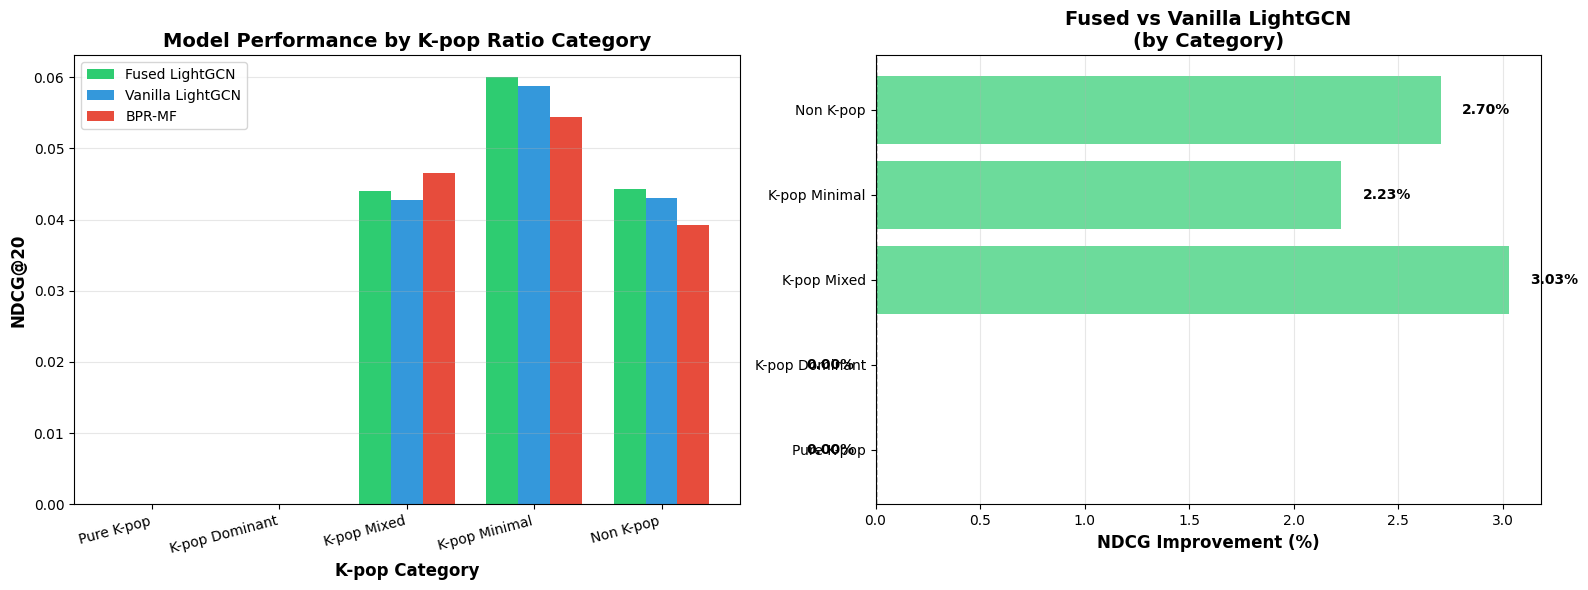


9) 결과 저장
✅ 결과 저장 완료: /content/drive/MyDrive/kpop_category_validation_results.json

10) 최종 요약

🎯 주요 발견사항:

1) 전체 평균 성능:
   Fused LightGCN:   NDCG@20 = 0.0495
   Vanilla LightGCN: NDCG@20 = 0.0482
   개선율: +2.61%

2) Fused LightGCN의 카테고리별 성능:
   K-pop Mixed         : NDCG = 0.0441 (1,627개 플레이리스트)
   K-pop Minimal       : NDCG = 0.0601 (18,535개 플레이리스트)
   Non K-pop           : NDCG = 0.0442 (17,794개 플레이리스트)

3) 모델 일관성 (낮을수록 일관적):
   Fused LightGCN      : CV = 0.1515
   Vanilla LightGCN    : CV = 0.1547
   BPR-MF              : CV = 0.1316

4) K-pop 중심 카테고리 (Pure/Dominant/Mixed) 평균:
   Fused:   0.0441
   Vanilla: 0.0428
   개선율:  +3.03%

✅ K-pop 비율별 일관성 검증 완료!


In [16]:
# -*- coding: utf-8 -*-
"""
K-pop 비율별 플레이리스트 카테고리에서의 모델 일관성 검증
- 각 K-pop 비율 카테고리별로 성능 측정
- 카테고리 간 성능 변화 분석
- 모델의 강건성(robustness) 검증
"""

import os
import json
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

print("="*70)
print("K-pop 비율별 모델 일관성 검증")
print("="*70)

# ===================================================================
# 1. 데이터 및 모델 로드 (이전 셀에서 이미 로드됨을 가정)
# ===================================================================
print("\n" + "="*70)
print("1) 기존 변수 확인")
print("="*70)

# 필수 변수 체크
required_vars = [
    'kpop_song_ids', 'val_df', 'val_records',
    'plylst_id_to_idx', 'song_id_to_idx',
    'fused_model', 'vanilla_model', 'bpr_model'
]

missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    print(f"⚠️ 누락된 변수: {missing_vars}")
    print("이전 셀들을 먼저 실행해주세요.")
    raise RuntimeError("필수 변수 누락")

print("✅ 모든 필수 변수 확인 완료")
print(f"  - K-pop 곡 수: {len(kpop_song_ids):,}")
print(f"  - 검증 플레이리스트: {len(val_records):,}")

# ===================================================================
# 2. K-pop 비율별 플레이리스트 분류
# ===================================================================
print("\n" + "="*70)
print("2) K-pop 비율별 플레이리스트 분류")
print("="*70)

def classify_playlist_kpop_type(songs, kpop_song_ids):
    """플레이리스트의 K-pop 강도 분류"""
    if not songs:
        return 'Non K-pop', 0.0

    kpop_count = sum(1 for s in songs if s in kpop_song_ids)
    kpop_ratio = kpop_count / len(songs)

    if kpop_ratio == 1.0:
        return 'Pure K-pop', kpop_ratio
    elif kpop_ratio >= 0.5:
        return 'K-pop Dominant', kpop_ratio
    elif kpop_ratio >= 0.1:
        return 'K-pop Mixed', kpop_ratio
    elif kpop_ratio > 0:
        return 'K-pop Minimal', kpop_ratio
    else:
        return 'Non K-pop', kpop_ratio

# val_records를 K-pop 비율별로 분류
categorized_records = {
    'Pure K-pop': [],
    'K-pop Dominant': [],
    'K-pop Mixed': [],
    'K-pop Minimal': [],
    'Non K-pop': []
}

print("\n플레이리스트 분류 중...")
for rec in tqdm(val_records, desc="분류 진행"):
    # train_songs + target_songs 전체로 분류
    all_songs = rec.get('train_songs', []) + rec.get('target_songs', [])
    category, ratio = classify_playlist_kpop_type(all_songs, kpop_song_ids)
    categorized_records[category].append(rec)

print("\n📊 카테고리별 플레이리스트 분포:")
total_playlists = sum(len(v) for v in categorized_records.values())
for category, records in categorized_records.items():
    count = len(records)
    pct = (count / total_playlists * 100) if total_playlists > 0 else 0
    print(f"  {category:20s}: {count:6,}개 ({pct:5.2f}%)")

# ===================================================================
# 3. 카테고리별 평가 함수
# ===================================================================
print("\n" + "="*70)
print("3) 카테고리별 평가 함수 정의")
print("="*70)

@torch.no_grad()
def evaluate_by_category(model, category_records, model_type='lightgcn', k=20):
    """특정 카테고리의 플레이리스트에 대해 평가"""
    if not category_records:
        return {'precision': 0.0, 'recall': 0.0, 'ndcg': 0.0, 'count': 0}

    if model_type == 'lightgcn':
        all_user_emb, all_item_emb = model()
    else:  # 'bpr'
        all_user_emb, all_item_emb = model.get_all_embeddings()

    precisions, recalls, ndcgs = [], [], []

    for rec in tqdm(category_records, desc="평가 중", leave=False):
        u = plylst_id_to_idx.get(rec['id'])
        if u is None:
            continue

        targets = rec.get('target_songs', [])
        trains = rec.get('train_songs', [])
        if not targets:
            continue

        scores = torch.matmul(all_user_emb[u], all_item_emb.T)

        # train_songs 마스킹
        mask_idx = [song_id_to_idx.get(s) for s in trains]
        mask_idx = [i for i in mask_idx if i is not None]
        if mask_idx:
            mi = torch.tensor(mask_idx, device=scores.device, dtype=torch.long)
            scores[mi] = float('-inf')

        _, topk = torch.topk(scores, k=k)
        topk_set = set(topk.detach().cpu().numpy())

        # 정답 인덱스
        tgt_idx = [song_id_to_idx.get(s) for s in targets]
        tgt_idx = set([i for i in tgt_idx if i is not None])

        hit = len(tgt_idx.intersection(topk_set))
        precisions.append(hit / k)
        recalls.append(hit / max(1, len(tgt_idx)))

        # NDCG
        dcg = 0.0
        arr = topk.detach().cpu().numpy()
        for rank, it in enumerate(arr):
            if it in tgt_idx:
                dcg += 1 / np.log2(rank + 2)
        idcg = sum([1 / np.log2(i + 2) for i in range(min(len(tgt_idx), k))]) + 1e-8
        ndcgs.append(dcg / idcg)

    return {
        'precision': float(np.mean(precisions)) if precisions else 0.0,
        'recall': float(np.mean(recalls)) if recalls else 0.0,
        'ndcg': float(np.mean(ndcgs)) if ndcgs else 0.0,
        'count': len(precisions)
    }

print("✅ 평가 함수 준비 완료")

# ===================================================================
# 4. 모델별 카테고리 성능 측정
# ===================================================================
print("\n" + "="*70)
print("4) 모델별 K-pop 비율 카테고리 성능 측정")
print("="*70)

K = 20
categories = ['Pure K-pop', 'K-pop Dominant', 'K-pop Mixed', 'K-pop Minimal', 'Non K-pop']

results_by_category = {
    'Fused LightGCN': {},
    'Vanilla LightGCN': {},
    'BPR-MF': {}
}

# Fused LightGCN 평가
print(f"\n🔍 Fused LightGCN (연구 모델) 카테고리별 평가...")
for category in categories:
    print(f"  • {category}")
    results_by_category['Fused LightGCN'][category] = evaluate_by_category(
        fused_model, categorized_records[category], 'lightgcn', K
    )

# Vanilla LightGCN 평가
print(f"\n🔍 Vanilla LightGCN 카테고리별 평가...")
for category in categories:
    print(f"  • {category}")
    results_by_category['Vanilla LightGCN'][category] = evaluate_by_category(
        vanilla_model, categorized_records[category], 'lightgcn', K
    )

# BPR-MF 평가
print(f"\n🔍 BPR-MF 카테고리별 평가...")
for category in categories:
    print(f"  • {category}")
    results_by_category['BPR-MF'][category] = evaluate_by_category(
        bpr_model, categorized_records[category], 'bpr', K
    )

# ===================================================================
# 5. 결과 정리 및 출력
# ===================================================================
print("\n" + "="*70)
print("5) 카테고리별 성능 결과")
print("="*70)

# DataFrame으로 정리
summary_data = []
for model_name in ['Fused LightGCN', 'Vanilla LightGCN', 'BPR-MF']:
    for category in categories:
        res = results_by_category[model_name][category]
        summary_data.append({
            'Model': model_name,
            'Category': category,
            'Count': res['count'],
            f'Precision@{K}': res['precision'],
            f'Recall@{K}': res['recall'],
            f'NDCG@{K}': res['ndcg']
        })

df_summary = pd.DataFrame(summary_data)

print("\n📊 전체 결과표:")
print(df_summary.to_string(index=False))

# ===================================================================
# 6. 카테고리별 성능 비교 (Fused vs Vanilla)
# ===================================================================
print("\n" + "="*70)
print("6) Fused vs Vanilla 카테고리별 개선율")
print("="*70)

improvement_data = []
for category in categories:
    fused = results_by_category['Fused LightGCN'][category]
    vanilla = results_by_category['Vanilla LightGCN'][category]

    if vanilla['ndcg'] > 0:
        ndcg_gain = ((fused['ndcg'] - vanilla['ndcg']) / vanilla['ndcg']) * 100
        recall_gain = ((fused['recall'] - vanilla['recall']) / vanilla['recall']) * 100
    else:
        ndcg_gain = 0.0
        recall_gain = 0.0

    improvement_data.append({
        'Category': category,
        'Count': fused['count'],
        'Fused NDCG': fused['ndcg'],
        'Vanilla NDCG': vanilla['ndcg'],
        'NDCG Gain(%)': ndcg_gain,
        'Recall Gain(%)': recall_gain
    })

df_improvement = pd.DataFrame(improvement_data)
print("\n💡 개선율 분석:")
print(df_improvement.to_string(index=False))

# ===================================================================
# 7. 일관성 지표 계산
# ===================================================================
print("\n" + "="*70)
print("7) 모델 일관성(Robustness) 분석")
print("="*70)

def calculate_consistency_metrics(model_results):
    """
    카테고리 간 성능 변동성(CV)을 계산하여 일관성 측정
    CV = std / mean (낮을수록 일관적)
    """
    ndcgs = [res['ndcg'] for res in model_results.values() if res['count'] > 0]
    recalls = [res['recall'] for res in model_results.values() if res['count'] > 0]

    if len(ndcgs) > 1:
        ndcg_cv = np.std(ndcgs) / (np.mean(ndcgs) + 1e-12)
        recall_cv = np.std(recalls) / (np.mean(recalls) + 1e-12)
    else:
        ndcg_cv = 0.0
        recall_cv = 0.0

    return {
        'NDCG_CV': ndcg_cv,
        'Recall_CV': recall_cv,
        'NDCG_Mean': np.mean(ndcgs) if ndcgs else 0.0,
        'Recall_Mean': np.mean(recalls) if recalls else 0.0
    }

consistency_results = {}
for model_name in ['Fused LightGCN', 'Vanilla LightGCN', 'BPR-MF']:
    consistency_results[model_name] = calculate_consistency_metrics(
        results_by_category[model_name]
    )

print("\n🎯 일관성 지표 (CV: Coefficient of Variation, 낮을수록 일관적):")
for model_name, metrics in consistency_results.items():
    print(f"\n{model_name}:")
    print(f"  NDCG CV:    {metrics['NDCG_CV']:.4f} (평균: {metrics['NDCG_Mean']:.4f})")
    print(f"  Recall CV:  {metrics['Recall_CV']:.4f} (평균: {metrics['Recall_Mean']:.4f})")

# 가장 일관적인 모델 찾기
best_consistency = min(consistency_results.items(),
                       key=lambda x: x[1]['NDCG_CV'])
print(f"\n✅ 가장 일관적인 모델: {best_consistency[0]} (NDCG CV: {best_consistency[1]['NDCG_CV']:.4f})")

# ===================================================================
# 8. 시각화
# ===================================================================
print("\n" + "="*70)
print("8) 결과 시각화")
print("="*70)

# 카테고리별 NDCG 비교 그래프
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 그래프 1: 카테고리별 NDCG
ax1 = axes[0]
x_pos = np.arange(len(categories))
width = 0.25

fused_ndcgs = [results_by_category['Fused LightGCN'][cat]['ndcg'] for cat in categories]
vanilla_ndcgs = [results_by_category['Vanilla LightGCN'][cat]['ndcg'] for cat in categories]
bpr_ndcgs = [results_by_category['BPR-MF'][cat]['ndcg'] for cat in categories]

ax1.bar(x_pos - width, fused_ndcgs, width, label='Fused LightGCN', color='#2ecc71')
ax1.bar(x_pos, vanilla_ndcgs, width, label='Vanilla LightGCN', color='#3498db')
ax1.bar(x_pos + width, bpr_ndcgs, width, label='BPR-MF', color='#e74c3c')

ax1.set_xlabel('K-pop Category', fontsize=12, fontweight='bold')
ax1.set_ylabel(f'NDCG@{K}', fontsize=12, fontweight='bold')
ax1.set_title(f'Model Performance by K-pop Ratio Category', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(categories, rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 그래프 2: 개선율
ax2 = axes[1]
improvements = df_improvement['NDCG Gain(%)'].values
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in improvements]

ax2.barh(categories, improvements, color=colors, alpha=0.7)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('NDCG Improvement (%)', fontsize=12, fontweight='bold')
ax2.set_title('Fused vs Vanilla LightGCN\n(by Category)', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for i, v in enumerate(improvements):
    ax2.text(v + 0.1 if v > 0 else v - 0.1, i, f'{v:.2f}%',
             va='center', ha='left' if v > 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'kpop_category_comparison.png'), dpi=150, bbox_inches='tight')
print("✅ 그래프 저장: kpop_category_comparison.png")
plt.show()

# ===================================================================
# 9. 결과 저장
# ===================================================================
print("\n" + "="*70)
print("9) 결과 저장")
print("="*70)

output_results = {
    'category_performance': results_by_category,
    'improvement_analysis': improvement_data,
    'consistency_metrics': consistency_results,
    'summary_table': summary_data
}

output_path = os.path.join(BASE_PATH, 'kpop_category_validation_results.json')
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(output_results, f, indent=2, ensure_ascii=False)

print(f"✅ 결과 저장 완료: {output_path}")

# ===================================================================
# 10. 최종 요약
# ===================================================================
print("\n" + "="*70)
print("10) 최종 요약")
print("="*70)

print("\n🎯 주요 발견사항:")

# 1. 전체 성능
overall_fused = np.mean([res['ndcg'] for res in results_by_category['Fused LightGCN'].values() if res['count'] > 0])
overall_vanilla = np.mean([res['ndcg'] for res in results_by_category['Vanilla LightGCN'].values() if res['count'] > 0])
print(f"\n1) 전체 평균 성능:")
print(f"   Fused LightGCN:   NDCG@{K} = {overall_fused:.4f}")
print(f"   Vanilla LightGCN: NDCG@{K} = {overall_vanilla:.4f}")
print(f"   개선율: +{((overall_fused - overall_vanilla) / overall_vanilla * 100):.2f}%")

# 2. 카테고리별 최고/최저 성능
print(f"\n2) Fused LightGCN의 카테고리별 성능:")
for category in categories:
    res = results_by_category['Fused LightGCN'][category]
    if res['count'] > 0:
        print(f"   {category:20s}: NDCG = {res['ndcg']:.4f} ({res['count']:,}개 플레이리스트)")

# 3. 일관성
print(f"\n3) 모델 일관성 (낮을수록 일관적):")
for model_name in ['Fused LightGCN', 'Vanilla LightGCN', 'BPR-MF']:
    cv = consistency_results[model_name]['NDCG_CV']
    print(f"   {model_name:20s}: CV = {cv:.4f}")

# 4. K-pop 중심 카테고리에서의 우위
kpop_focused_categories = ['Pure K-pop', 'K-pop Dominant', 'K-pop Mixed']
fused_kpop_avg = np.mean([results_by_category['Fused LightGCN'][cat]['ndcg']
                          for cat in kpop_focused_categories
                          if results_by_category['Fused LightGCN'][cat]['count'] > 0])
vanilla_kpop_avg = np.mean([results_by_category['Vanilla LightGCN'][cat]['ndcg']
                            for cat in kpop_focused_categories
                            if results_by_category['Vanilla LightGCN'][cat]['count'] > 0])

print(f"\n4) K-pop 중심 카테고리 (Pure/Dominant/Mixed) 평균:")
print(f"   Fused:   {fused_kpop_avg:.4f}")
print(f"   Vanilla: {vanilla_kpop_avg:.4f}")
print(f"   개선율:  +{((fused_kpop_avg - vanilla_kpop_avg) / vanilla_kpop_avg * 100):.2f}%")

print("\n" + "="*70)
print("✅ K-pop 비율별 일관성 검증 완료!")
print("="*70)